# 미니프로젝트: 차원 축소와 SHAP Value (Vibe Coding)

#### <목표>
오늘 배운 **mRMR, Boruta, SHAP Value**를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>

| 변수명 | 설명 |
|:---:|:---|
| gender, SeniorCitizen, Partner, Dependents | 고객 인적사항 |
| tenure | 가입 개월 수 |
| PhoneService, MultipleLines, InternetService 등 | 가입 서비스 종류 |
| Contract, PaperlessBilling, PaymentMethod | 계약/결제 정보 |
| MonthlyCharges, TotalCharges | 월/누적 요금 |
| Churn | 이탈 여부 (Yes: 이탈, No: 유지) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `Churn` | 인코딩된 고객 정보로 이탈 여부 예측 및 변수 해석 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day5_miniproject.csv` 파일을 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)
- 지난 미니프로젝트에서 다룬 전처리를 모두 적용한 뒤 시작하세요.

**[과제]** 써니는 어제 실습에서 사용한 통신사 고객 이탈(Churn) 데이터를 활용하여 분석을 진행하고자 합니다. 필요한 라이브러리와 데이터를 불러오세요.

In [1]:
# 기본 라이브러리 및 시각화 설정
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

# 1. Seaborn 테마 사용: 전체 시각화 스타일을 통일합니다.
sns.set_theme(style="whitegrid", context="notebook", palette="Set2")


def setup_korean_font():
    """OS별 한글 폰트를 찾아 설정하고, 실패해도 그래프가 그려지도록 예외 처리합니다."""
    candidates = [
        "Malgun Gothic",      # Windows
        "AppleGothic",        # macOS
        "NanumGothic",        # Linux/Colab
        "Noto Sans CJK KR",
        "Noto Sans KR",
    ]
    try:
        available_fonts = {font.name for font in fm.fontManager.ttflist}
        for font_name in candidates:
            if font_name in available_fonts:
                plt.rcParams["font.family"] = font_name
                plt.rcParams["axes.unicode_minus"] = False
                print(f"한글 폰트 설정 완료: {font_name}")
                return font_name
        raise RuntimeError("사용 가능한 한글 폰트를 찾지 못했습니다.")
    except Exception as exc:
        plt.rcParams["font.family"] = "DejaVu Sans"
        plt.rcParams["axes.unicode_minus"] = False
        print(f"한글 폰트 자동 설정 실패: {exc}")
        print("그래프는 계속 출력됩니다. 한글이 깨지면 Malgun Gothic 또는 NanumGothic 설치를 확인하세요.")
        return None


setup_korean_font()

# 노트북 실행 위치가 달라도 데이터를 찾을 수 있도록 후보 경로를 둡니다.
data_candidates = [
    Path("dataset/day5_miniproject.csv"),
    Path("12일차/dataset/day5_miniproject.csv"),
    Path(r"D:\autornd\SK Autonomous R&D\실습\12일차\dataset\day5_miniproject.csv"),
]

for path in data_candidates:
    if path.exists():
        DATA_PATH = path
        break
else:
    raise FileNotFoundError("day5_miniproject.csv 파일을 찾지 못했습니다. dataset 폴더 경로를 확인하세요.")

df_raw = pd.read_csv(DATA_PATH)

print(f"데이터 경로: {DATA_PATH}")
print(f"데이터 크기: {df_raw.shape[0]:,}행 x {df_raw.shape[1]:,}열")
display(df_raw.head())
display(df_raw.info())

한글 폰트 설정 완료: Malgun Gothic
데이터 경로: dataset\day5_miniproject.csv
데이터 크기: 7,043행 x 20열


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            6832 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   6903 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     6832 non-null   object 


None

**[과제]** 써니는 어제 진행한 통신사 고객 이탈 데이터 전처리 과정을 재사용하고자 합니다. Agent 기능을 활용하여 '머신러닝 Day4. 미니프로젝트.ipynb' 파일에서 전처리 코드를 찾아 실행하고 동일한 데이터 전처리 결과를 재현해 보세요.

> 입력변수, 출력변수 분할 / 학습 데이터, 테스트 데이터 분할 / 결측치 처리 / 스케일링, 인코딩

In [2]:
# Day 4 미니프로젝트 전처리 재현
# - Churn 0/1 변환
# - TotalCharges 숫자화 및 신규 고객 결측 보정
# - 입력/출력 분할, stratified train/test split
# - 수치형: 결측치 대치 + 스케일링
# - 범주형: 결측치 대치 + 원-핫 인코딩

df = df_raw.copy()

# 1) TotalCharges: 문자열/공백이 섞여 있어도 숫자로 변환
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# 2) Churn: No/Yes -> 0/1
churn_map = {"No": 0, "Yes": 1, 0: 0, 1: 1}
df["Churn"] = df["Churn"].map(churn_map).astype("int64")

# 3) tenure=0 신규 고객의 TotalCharges 결측은 MonthlyCharges로 대치
mask_new_customer = (df["tenure"] == 0) & (df["TotalCharges"].isna())
filled_count = int(mask_new_customer.sum())
df.loc[mask_new_customer, "TotalCharges"] = df.loc[mask_new_customer, "MonthlyCharges"]

X = df.drop(columns="Churn")
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

try:
    encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", encoder),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

X_train_array = preprocessor.fit_transform(X_train)
X_test_array = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

X_train_processed = pd.DataFrame(X_train_array, columns=feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_array, columns=feature_names, index=X_test.index)

print("=" * 70)
print("전처리 결과")
print("=" * 70)
print(f"TotalCharges 신규 고객 결측 대치: {filled_count:,}건")
print(f"수치형 변수: {numeric_features}")
print(f"범주형 변수: {categorical_features}")
print(f"학습 데이터: {X_train_processed.shape}")
print(f"테스트 데이터: {X_test_processed.shape}")

split_summary = pd.DataFrame({
    "학습 건수": y_train.value_counts().sort_index(),
    "테스트 건수": y_test.value_counts().sort_index(),
    "학습 비율(%)": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "테스트 비율(%)": (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
})
split_summary.index = ["유지(0)", "이탈(1)"]
display(split_summary)

display(X_train_processed.head())

전처리 결과
TotalCharges 신규 고객 결측 대치: 11건
수치형 변수: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
범주형 변수: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
학습 데이터: (5634, 30)
테스트 데이터: (1409, 30)


,학습 건수,테스트 건수,학습 비율(%),테스트 비율(%)
유지(0),4139,1035,73.46,73.46
이탈(1),1495,374,26.54,26.54


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,-0.441773,0.108522,-0.537179,-0.262290,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3151,-0.441773,-0.717654,0.336316,-0.503674,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4860,-0.441773,-0.139331,-0.828906,-0.749929,1.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3867,-0.441773,-0.263257,0.282355,-0.172753,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
3810,-0.441773,-1.295977,-0.694003,-0.989426,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 1) 다중공선성 확인

**[과제]** 써니는 인코딩된 변수들의 상관행렬을 히트맵으로 그려보고 어떤 변수끼리 상관관계가 높은지 AI와 함께 확인해 보세요.

상관계수 절댓값이 높은 변수쌍 Top 15


,변수1,변수2,corr,|corr|
291,OnlineSecurity_No internet service,StreamingMovies_No internet service,1.0,1.0
391,StreamingTV_No internet service,StreamingMovies_No internet service,1.0,1.0
289,OnlineSecurity_No internet service,StreamingTV_No internet service,1.0,1.0
287,OnlineSecurity_No internet service,TechSupport_No internet service,1.0,1.0
285,OnlineSecurity_No internet service,DeviceProtection_No internet service,1.0,1.0
283,OnlineSecurity_No internet service,OnlineBackup_No internet service,1.0,1.0
345,DeviceProtection_No internet service,TechSupport_No internet service,1.0,1.0
347,DeviceProtection_No internet service,StreamingTV_No internet service,1.0,1.0
322,OnlineBackup_No internet service,StreamingMovies_No internet service,1.0,1.0
320,OnlineBackup_No internet service,StreamingTV_No internet service,1.0,1.0


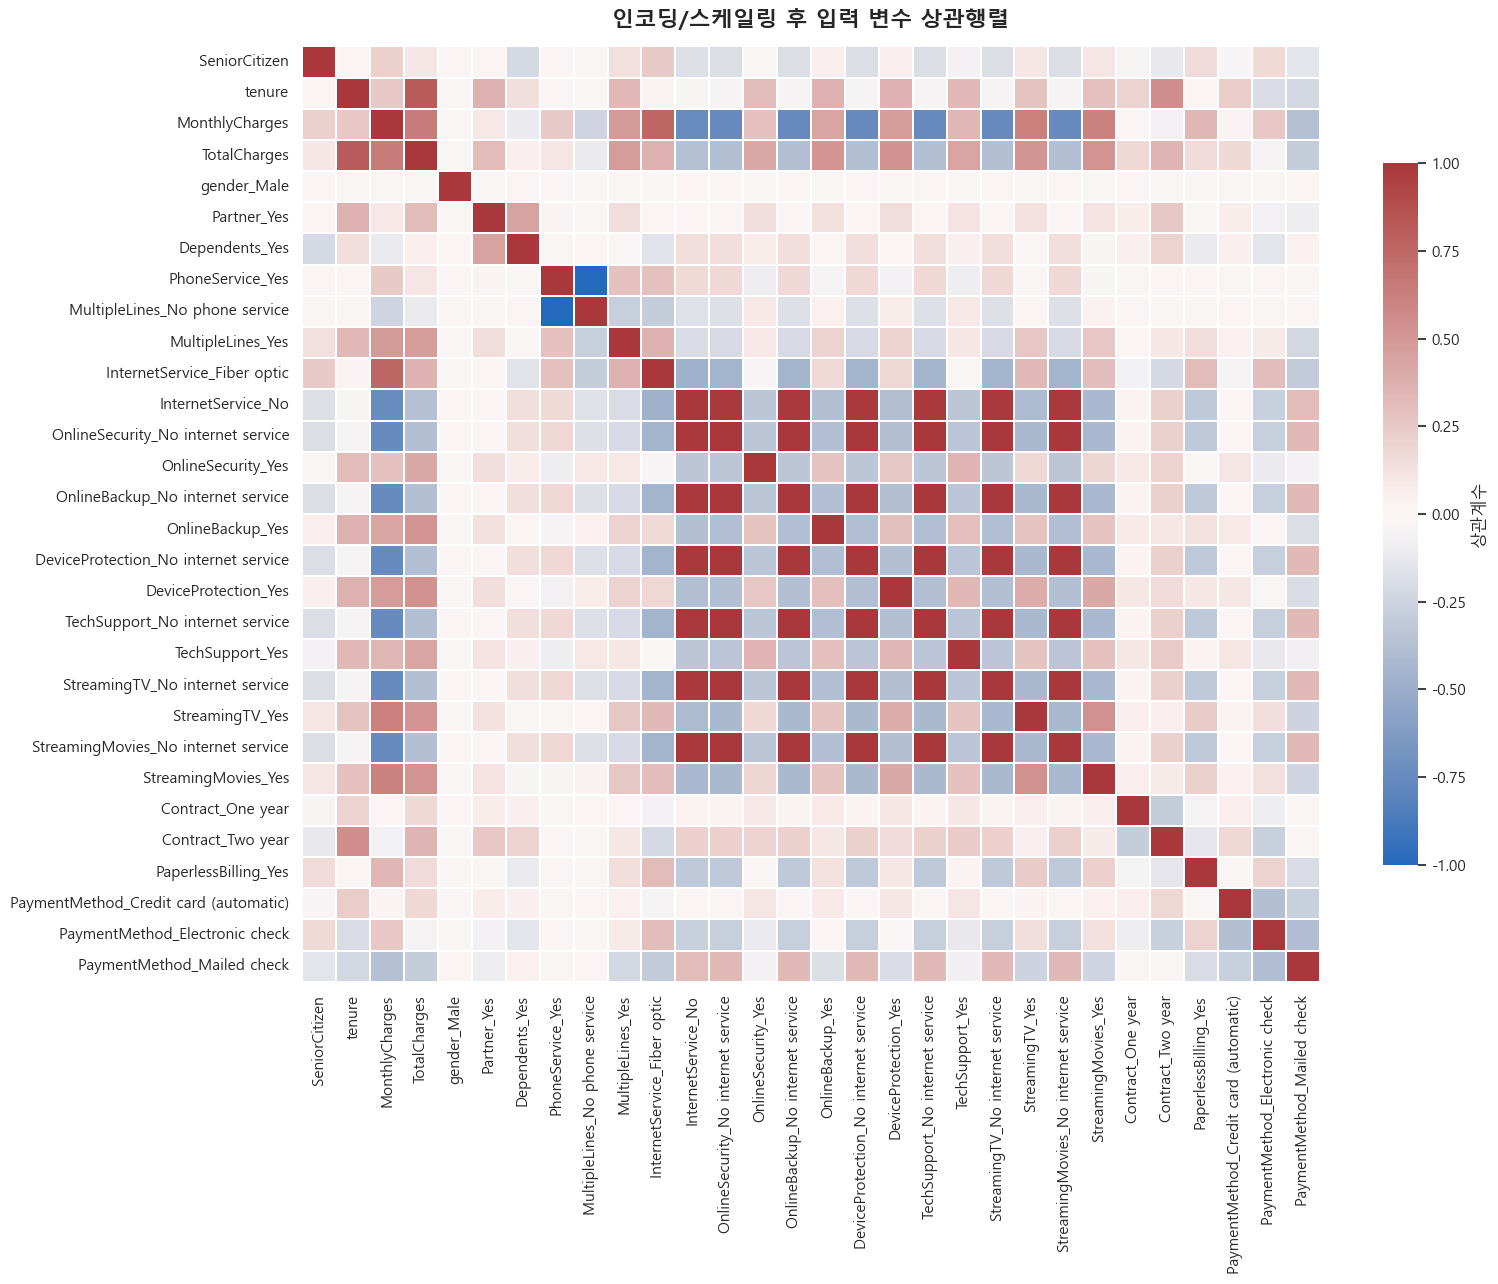

|corr| >= 0.65인 변수쌍: 31개


,변수1,변수2,corr,|corr|
291,OnlineSecurity_No internet service,StreamingMovies_No internet service,1.000000,1.000000
391,StreamingTV_No internet service,StreamingMovies_No internet service,1.000000,1.000000
289,OnlineSecurity_No internet service,StreamingTV_No internet service,1.000000,1.000000
287,OnlineSecurity_No internet service,TechSupport_No internet service,1.000000,1.000000
285,OnlineSecurity_No internet service,DeviceProtection_No internet service,1.000000,1.000000
283,OnlineSecurity_No internet service,OnlineBackup_No internet service,1.000000,1.000000
345,DeviceProtection_No internet service,TechSupport_No internet service,1.000000,1.000000
347,DeviceProtection_No internet service,StreamingTV_No internet service,1.000000,1.000000
322,OnlineBackup_No internet service,StreamingMovies_No internet service,1.000000,1.000000
320,OnlineBackup_No internet service,StreamingTV_No internet service,1.000000,1.000000


해석 가이드
- 절댓값이 1에 가까울수록 두 변수가 거의 같은 정보를 담고 있을 가능성이 큽니다.
- mRMR은 이런 중복 정보를 줄이면서 타겟과 관련성이 높은 변수를 고르는 데 유리합니다.
- Boruta는 중복 여부와 별개로 예측에 유용한 모든 관련 변수를 폭넓게 남기는 경향이 있습니다.


In [3]:
# 인코딩된 변수들의 상관행렬 확인
corr_matrix = X_train_processed.corr()

# 중복 제거를 위해 상삼각 행렬만 확인
upper_mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
high_corr_pairs = (
    corr_matrix.where(upper_mask)
    .stack()
    .rename("corr")
    .reset_index()
    .rename(columns={"level_0": "변수1", "level_1": "변수2"})
)
high_corr_pairs["|corr|"] = high_corr_pairs["corr"].abs()
high_corr_pairs = high_corr_pairs.sort_values("|corr|", ascending=False)

print("상관계수 절댓값이 높은 변수쌍 Top 15")
display(high_corr_pairs.head(15))

plt.figure(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    cmap="vlag",
    center=0,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"shrink": 0.75, "label": "상관계수"},
)
plt.title("인코딩/스케일링 후 입력 변수 상관행렬", fontsize=16, fontweight="bold", pad=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

strong_threshold = 0.65
strong_pairs = high_corr_pairs[high_corr_pairs["|corr|"] >= strong_threshold]
print(f"|corr| >= {strong_threshold}인 변수쌍: {len(strong_pairs):,}개")
display(strong_pairs)

print("해석 가이드")
print("- 절댓값이 1에 가까울수록 두 변수가 거의 같은 정보를 담고 있을 가능성이 큽니다.")
print("- mRMR은 이런 중복 정보를 줄이면서 타겟과 관련성이 높은 변수를 고르는 데 유리합니다.")
print("- Boruta는 중복 여부와 별개로 예측에 유용한 모든 관련 변수를 폭넓게 남기는 경향이 있습니다.")

**[과제]** 써니는 변수 선택법과 SHAP 분석을 적용하기 전에 전체 변수를 사용한 Random Forest 분류 모델의 성능을 기준으로 삼고자 합니다. AI와 상의하여 모델을 학습하고, Accuracy, Precision, Recall, F1-score를 계산하여 성능을 확인하는 코드를 작성해 보세요.

,변수 수,Accuracy,Precision,Recall,F1-score
Method,,,,,
전체 변수,30,0.787,0.627,0.489,0.550


[전체 변수 모델 Classification Report]
              precision    recall  f1-score   support

       유지(0)       0.83      0.89      0.86      1035
       이탈(1)       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



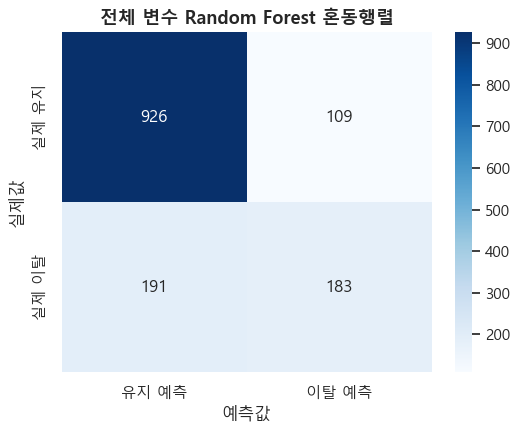

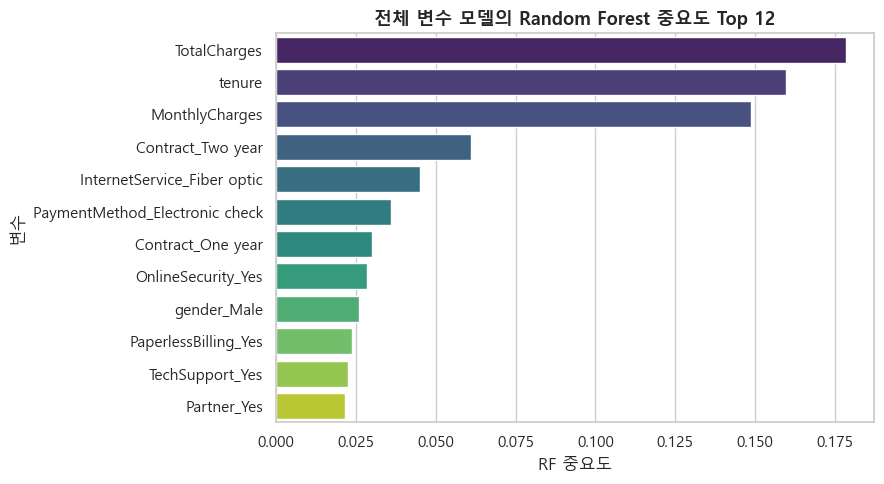

,변수,RF 중요도
3,TotalCharges,0.178325
1,tenure,0.159697
2,MonthlyCharges,0.148600
25,Contract_Two year,0.061117
10,InternetService_Fiber optic,0.045067
28,PaymentMethod_Electronic check,0.035881
24,Contract_One year,0.029974
13,OnlineSecurity_Yes,0.028591
4,gender_Male,0.025930
26,PaperlessBilling_Yes,0.023700


In [4]:
# 전체 변수를 사용한 Random Forest 기준 모델

def evaluate_rf_model(method_name, X_tr, X_te, y_tr, y_te, feature_list, n_estimators=300):
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
        max_depth=None,
    )
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    metrics = {
        "Method": method_name,
        "변수 수": len(feature_list),
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred, zero_division=0),
        "Recall": recall_score(y_te, pred, zero_division=0),
        "F1-score": f1_score(y_te, pred, zero_division=0),
    }
    return model, pred, metrics


model_registry = {}
results_records = []

all_features = X_train_processed.columns.tolist()
baseline_model, baseline_pred, baseline_metrics = evaluate_rf_model(
    "전체 변수",
    X_train_processed,
    X_test_processed,
    y_train,
    y_test,
    all_features,
)

model_registry["전체 변수"] = {
    "model": baseline_model,
    "features": all_features,
    "X_train": X_train_processed,
    "X_test": X_test_processed,
    "pred": baseline_pred,
}
results_records.append(baseline_metrics)

baseline_result = pd.DataFrame([baseline_metrics]).set_index("Method")
display(baseline_result.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-score": "{:.3f}",
}))

print("[전체 변수 모델 Classification Report]")
print(classification_report(y_test, baseline_pred, target_names=["유지(0)", "이탈(1)"], zero_division=0))

cm = confusion_matrix(y_test, baseline_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    xticklabels=["유지 예측", "이탈 예측"],
    yticklabels=["실제 유지", "실제 이탈"],
)
plt.title("전체 변수 Random Forest 혼동행렬", fontsize=13, fontweight="bold")
plt.xlabel("예측값")
plt.ylabel("실제값")
plt.tight_layout()
plt.show()

importance_all = pd.DataFrame({
    "변수": all_features,
    "RF 중요도": baseline_model.feature_importances_,
}).sort_values("RF 중요도", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_all.head(12), x="RF 중요도", y="변수", palette="viridis")
plt.title("전체 변수 모델의 Random Forest 중요도 Top 12", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

display(importance_all.head(12))

## 2) mRMR 변수 선택

**[과제]** 써니는 mRMR을 활용해 중요한 변수를 선택해보고자 합니다. AI와 상의해서 가장 적합한 k를 결정하고 선택된 변수로 모델을 다시 학습시켜 전체 변수를 사용했을 때 때와 성능을 비교해 보세요.

mrmr_classif 사용 가능: 실제 mRMR로 변수 선택을 수행합니다.


100%|██████████| 25/25 [00:04<00:00,  5.05it/s]


,Method,변수 수,Accuracy,Precision,Recall,F1-score
1,mRMR (k=8),8,0.744,0.513,0.714,0.597
2,mRMR (k=10),10,0.733,0.498,0.674,0.573
3,mRMR (k=12),12,0.745,0.516,0.636,0.570
0,mRMR (k=5),5,0.720,0.481,0.698,0.569
6,mRMR (k=25),25,0.780,0.606,0.489,0.541
4,mRMR (k=15),15,0.746,0.520,0.556,0.537
5,mRMR (k=20),20,0.761,0.561,0.457,0.504


최종 mRMR 선택: mRMR (k=8)
선택 변수 8개
['tenure', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'Contract_Two year', 'PaperlessBilling_Yes', 'OnlineSecurity_Yes', 'Contract_One year', 'OnlineSecurity_No internet service']
              precision    recall  f1-score   support

       유지(0)       0.88      0.76      0.81      1035
       이탈(1)       0.51      0.71      0.60       374

    accuracy                           0.74      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.74      0.76      1409



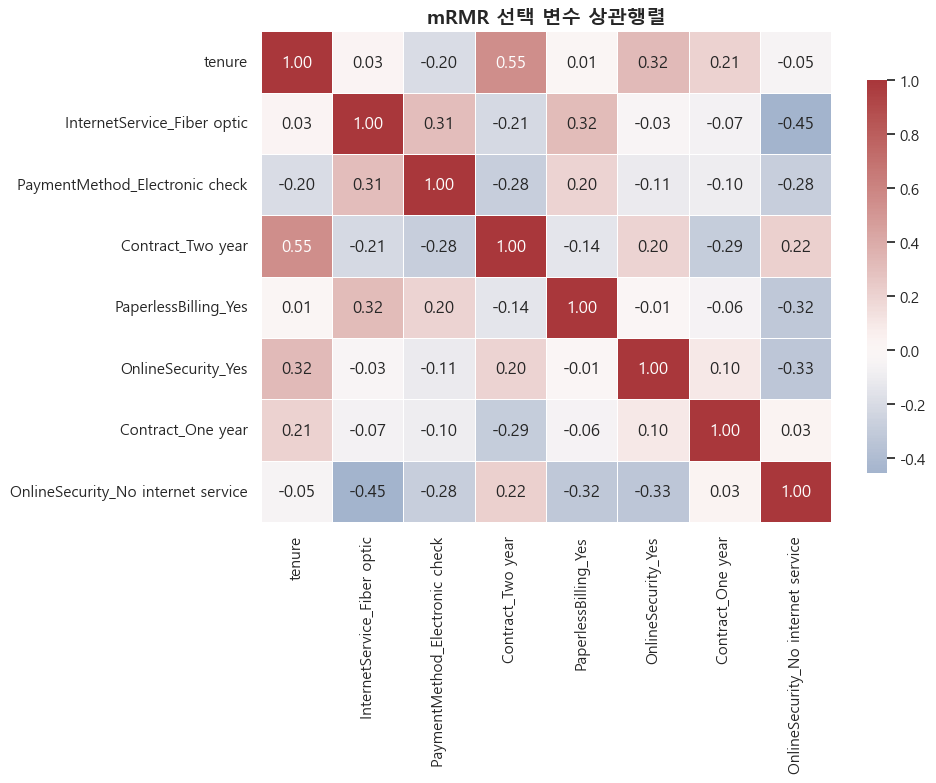

In [5]:
# mRMR 변수 선택
# 분류 문제이므로 mrmr_classif를 우선 사용합니다.
# 패키지가 없는 환경에서도 실행이 끊기지 않도록 mutual information + 상관 중복 완화 방식으로 대체합니다.


def fallback_mrmr_like(X_df, y_series, k, redundancy_threshold=0.85):
    mi = mutual_info_classif(X_df, y_series, random_state=42)
    relevance = pd.Series(mi, index=X_df.columns).sort_values(ascending=False)

    selected = []
    for col in relevance.index:
        if len(selected) >= k:
            break
        if not selected:
            selected.append(col)
            continue
        max_redundancy = X_df[selected + [col]].corr().abs().loc[col, selected].max()
        if max_redundancy < redundancy_threshold:
            selected.append(col)

    # 상관 기준 때문에 k개를 못 채우면 관련도 순서대로 보충
    for col in relevance.index:
        if len(selected) >= k:
            break
        if col not in selected:
            selected.append(col)
    return selected


try:
    from mrmr import mrmr_classif
    mrmr_available = True
    print("mrmr_classif 사용 가능: 실제 mRMR로 변수 선택을 수행합니다.")
except Exception as exc:
    mrmr_available = False
    print(f"mrmr_classif import 실패: {exc}")
    print("대체 로직(mutual information + 중복 상관 완화)으로 진행합니다.")

max_features = X_train_processed.shape[1]
k_candidates = sorted(set([5, 8, 10, 12, 15, 20, min(25, max_features)]))
k_candidates = [k for k in k_candidates if 2 <= k <= max_features]

mrmr_trials = []
mrmr_selected_by_k = {}

for k in k_candidates:
    if mrmr_available:
        selected = mrmr_classif(X=X_train_processed, y=y_train, K=k)
    else:
        selected = fallback_mrmr_like(X_train_processed, y_train, k=k)

    selected = list(selected)
    mrmr_selected_by_k[k] = selected

    model, pred, metrics = evaluate_rf_model(
        f"mRMR (k={k})",
        X_train_processed[selected],
        X_test_processed[selected],
        y_train,
        y_test,
        selected,
    )
    mrmr_trials.append({**metrics, "model": model, "pred": pred, "features": selected})

mrmr_trial_df = pd.DataFrame([{k: v for k, v in row.items() if k not in ["model", "pred", "features"]} for row in mrmr_trials])
mrmr_trial_df = mrmr_trial_df.sort_values(["F1-score", "Recall", "변수 수"], ascending=[False, False, True])
display(mrmr_trial_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-score": "{:.3f}",
}))

best_mrmr_name = mrmr_trial_df.iloc[0]["Method"]
best_mrmr_trial = next(row for row in mrmr_trials if row["Method"] == best_mrmr_name)
selected_mrmr = best_mrmr_trial["features"]
mrmr_model = best_mrmr_trial["model"]
mrmr_pred = best_mrmr_trial["pred"]
mrmr_metrics = {k: v for k, v in best_mrmr_trial.items() if k not in ["model", "pred", "features"]}

model_registry[best_mrmr_name] = {
    "model": mrmr_model,
    "features": selected_mrmr,
    "X_train": X_train_processed[selected_mrmr],
    "X_test": X_test_processed[selected_mrmr],
    "pred": mrmr_pred,
}
results_records.append(mrmr_metrics)

print("=" * 70)
print(f"최종 mRMR 선택: {best_mrmr_name}")
print(f"선택 변수 {len(selected_mrmr)}개")
print(selected_mrmr)
print("=" * 70)
print(classification_report(y_test, mrmr_pred, target_names=["유지(0)", "이탈(1)"], zero_division=0))

plt.figure(figsize=(10, 8))
sns.heatmap(
    X_train_processed[selected_mrmr].corr(),
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("mRMR 선택 변수 상관행렬", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3) Boruta 변수 선택

**[과제]** 써니는 Boruta로도 변수를 선택해보고자 합니다. AI와 상의하여 관련 코드를 작성하세요.

BorutaPy 사용 가능: 실제 Boruta로 변수 선택을 수행합니다.
Boruta 확정 변수: 22개
Boruta 미정 변수: 0개
최종 Boruta 사용 변수 22개
['tenure', 'MonthlyCharges', 'TotalCharges', 'Partner_Yes', 'Dependents_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check']
              precision    recall  f1-score   support

       유지(0)       0.82      0.90      0.86      1035
       이탈(1)       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      140

,변수,RF 중요도
2,TotalCharges,0.216824
1,MonthlyCharges,0.186817
0,tenure,0.181969
18,Contract_Two year,0.060480
5,InternetService_Fiber optic,0.050522
21,PaymentMethod_Electronic check,0.041780
17,Contract_One year,0.030430
8,OnlineSecurity_Yes,0.028373
19,PaperlessBilling_Yes,0.025295
14,TechSupport_Yes,0.025219


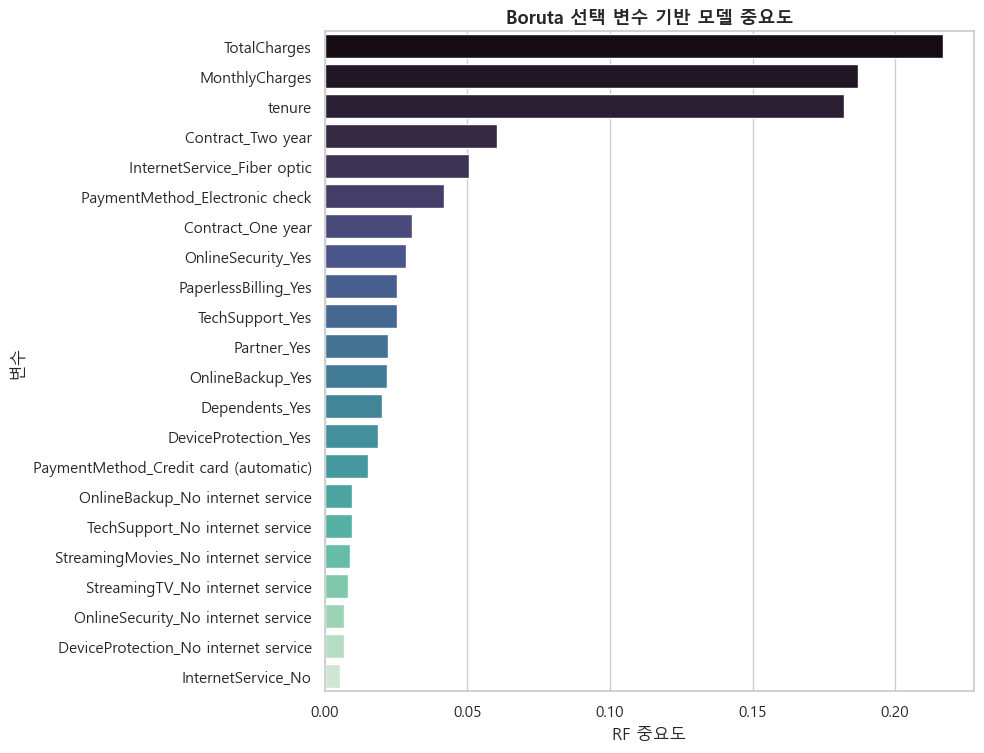

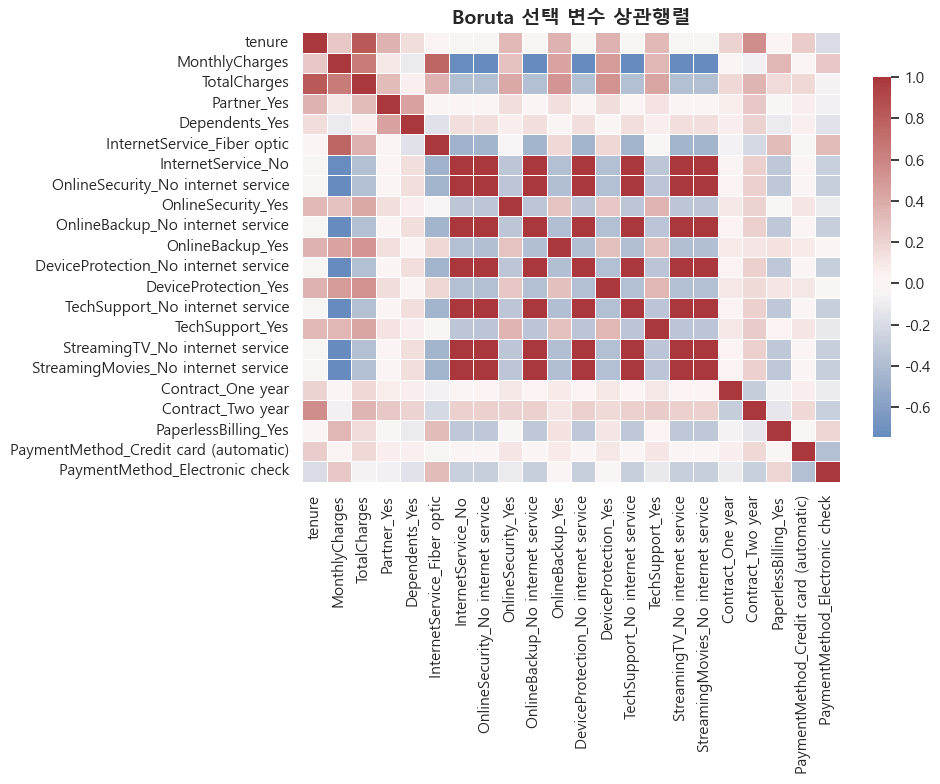

In [6]:
# Boruta 변수 선택
# Boruta는 Random Forest의 shadow feature와 비교해 예측에 관련 있는 변수를 선택합니다.

try:
    from boruta import BorutaPy
    boruta_available = True
    print("BorutaPy 사용 가능: 실제 Boruta로 변수 선택을 수행합니다.")
except Exception as exc:
    boruta_available = False
    print(f"BorutaPy import 실패: {exc}")
    print("대체 로직(Random Forest 중요도 상위 변수)으로 진행합니다.")

if boruta_available:
    rf_for_boruta = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
        max_depth=7,
    )
    boruta_selector = BorutaPy(
        estimator=rf_for_boruta,
        n_estimators="auto",
        max_iter=30,
        perc=90,
        random_state=42,
        verbose=0,
    )
    boruta_selector.fit(X_train_processed.values, y_train.values)

    confirmed_features = X_train_processed.columns[boruta_selector.support_].tolist()
    tentative_features = X_train_processed.columns[boruta_selector.support_weak_].tolist()

    print(f"Boruta 확정 변수: {len(confirmed_features)}개")
    print(f"Boruta 미정 변수: {len(tentative_features)}개")

    # 확정 변수가 너무 적으면 미정 변수까지 포함해 모델 안정성을 확보합니다.
    selected_boruta = confirmed_features.copy()
    if len(selected_boruta) < 3:
        selected_boruta = confirmed_features + tentative_features

    # 그래도 변수가 없으면 RF 중요도 상위 변수를 사용합니다.
    if len(selected_boruta) == 0:
        rf_fallback = RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1,
        )
        rf_fallback.fit(X_train_processed, y_train)
        fallback_n = max(5, min(12, X_train_processed.shape[1] // 3))
        selected_boruta = (
            pd.Series(rf_fallback.feature_importances_, index=X_train_processed.columns)
            .sort_values(ascending=False)
            .head(fallback_n)
            .index
            .tolist()
        )
else:
    rf_fallback = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    )
    rf_fallback.fit(X_train_processed, y_train)
    fallback_n = max(5, min(12, X_train_processed.shape[1] // 3))
    selected_boruta = (
        pd.Series(rf_fallback.feature_importances_, index=X_train_processed.columns)
        .sort_values(ascending=False)
        .head(fallback_n)
        .index
        .tolist()
    )

selected_boruta = list(dict.fromkeys(selected_boruta))

boruta_method_name = f"Boruta ({len(selected_boruta)}개)"
boruta_model, boruta_pred, boruta_metrics = evaluate_rf_model(
    boruta_method_name,
    X_train_processed[selected_boruta],
    X_test_processed[selected_boruta],
    y_train,
    y_test,
    selected_boruta,
)

model_registry[boruta_method_name] = {
    "model": boruta_model,
    "features": selected_boruta,
    "X_train": X_train_processed[selected_boruta],
    "X_test": X_test_processed[selected_boruta],
    "pred": boruta_pred,
}
results_records.append(boruta_metrics)

print("=" * 70)
print(f"최종 Boruta 사용 변수 {len(selected_boruta)}개")
print(selected_boruta)
print("=" * 70)
print(classification_report(y_test, boruta_pred, target_names=["유지(0)", "이탈(1)"], zero_division=0))

boruta_importance = pd.DataFrame({
    "변수": selected_boruta,
    "RF 중요도": boruta_model.feature_importances_,
}).sort_values("RF 중요도", ascending=False)

display(boruta_importance)

plt.figure(figsize=(10, max(4, len(selected_boruta) * 0.35)))
sns.barplot(data=boruta_importance, x="RF 중요도", y="변수", palette="mako")
plt.title("Boruta 선택 변수 기반 모델 중요도", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(
    X_train_processed[selected_boruta].corr(),
    cmap="vlag",
    center=0,
    annot=len(selected_boruta) <= 15,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Boruta 선택 변수 상관행렬", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4) 성능 비교 요약

**[과제]** 써니는 전체 변수/mRMR/Boruta 세 가지 방법의 성능을 표로 정리하고 변수 수를 줄였을 때 성능이 어떻게 변하는지 AI와 함께 해석해 보세요.

,Method,변수 수,Accuracy,Precision,Recall,F1-score
0,mRMR (k=8),8,0.744,0.513,0.714,0.597
1,전체 변수,30,0.787,0.627,0.489,0.550
2,Boruta (22개),22,0.787,0.633,0.471,0.540


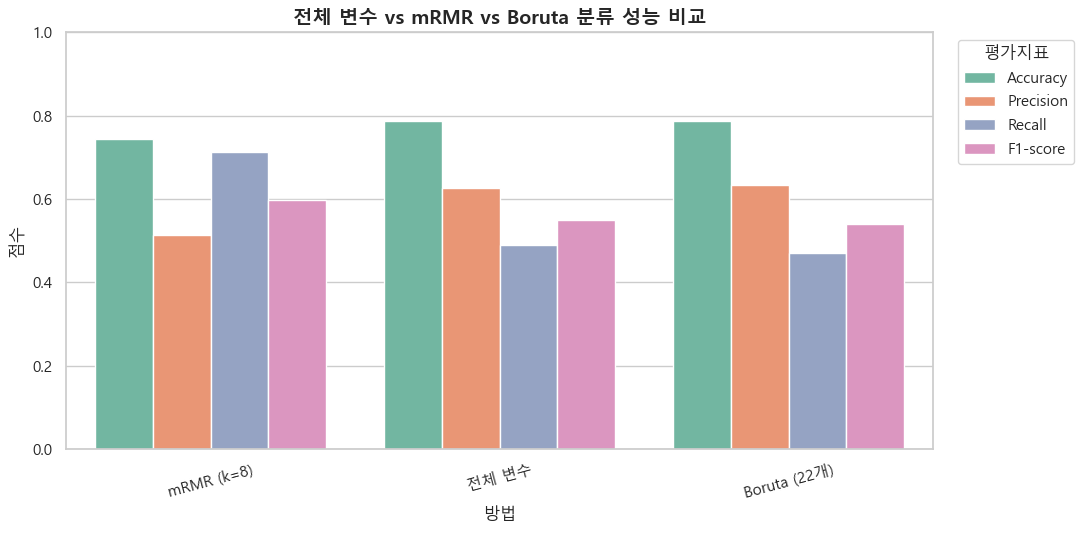

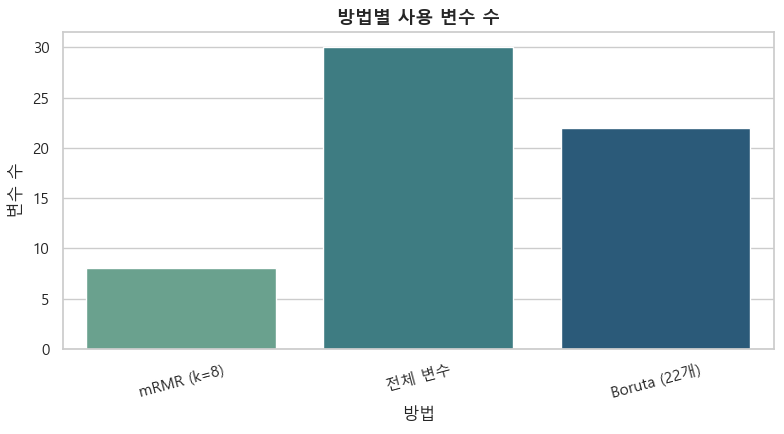

해석
- F1-score와 Recall을 기준으로 가장 우수한 모델은 'mRMR (k=8)'입니다.
- 전체 변수 모델보다 변수 선택 모델의 성능이 비슷하거나 높다면, 중복/잡음 변수를 줄인 효과가 있었다고 볼 수 있습니다.
- 변수 수가 줄었는데 Recall이 크게 떨어지지 않는다면, 이탈 고객 탐지에 필요한 핵심 정보가 잘 남아 있는 것입니다.
- 반대로 Recall이 낮아졌다면 실제 이탈 고객을 놓칠 위험이 커지므로 마케팅 목적에서는 주의가 필요합니다.


In [7]:
# 전체 변수 / mRMR / Boruta 성능 비교 요약
results_df = pd.DataFrame(results_records)
results_df = results_df.drop_duplicates(subset=["Method"], keep="last")
results_df = results_df.sort_values(["F1-score", "Recall", "Precision"], ascending=False).reset_index(drop=True)

styled_results = results_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-score": "{:.3f}",
}).background_gradient(subset=["Accuracy", "Precision", "Recall", "F1-score"], cmap="YlGn")

display(styled_results)

plot_results = results_df.melt(
    id_vars=["Method", "변수 수"],
    value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(11, 5.5))
sns.barplot(data=plot_results, x="Method", y="Score", hue="Metric")
plt.ylim(0, 1)
plt.title("전체 변수 vs mRMR vs Boruta 분류 성능 비교", fontsize=14, fontweight="bold")
plt.xlabel("방법")
plt.ylabel("점수")
plt.xticks(rotation=15)
plt.legend(title="평가지표", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
sns.barplot(data=results_df, x="Method", y="변수 수", palette="crest")
plt.title("방법별 사용 변수 수", fontsize=13, fontweight="bold")
plt.xlabel("방법")
plt.ylabel("변수 수")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_method = results_df.iloc[0]["Method"]
best_info = model_registry[best_method]

print("해석")
print(f"- F1-score와 Recall을 기준으로 가장 우수한 모델은 '{best_method}'입니다.")
print("- 전체 변수 모델보다 변수 선택 모델의 성능이 비슷하거나 높다면, 중복/잡음 변수를 줄인 효과가 있었다고 볼 수 있습니다.")
print("- 변수 수가 줄었는데 Recall이 크게 떨어지지 않는다면, 이탈 고객 탐지에 필요한 핵심 정보가 잘 남아 있는 것입니다.")
print("- 반대로 Recall이 낮아졌다면 실제 이탈 고객을 놓칠 위험이 커지므로 마케팅 목적에서는 주의가 필요합니다.")

## 5) SHAP Value로 이탈 요인 해석

**[과제]** 써니는 성능이 가장 좋았던 모델에 대해 SHAP TreeExplainer를 적용하고 Summary Plot으로 이탈에 가장 큰 영향을 미치는 변수 상위 10개를 확인해보고자 합니다. AI를 활용해 관련 코드를 작성해보세요.

SHAP 분석 대상 모델: mRMR (k=8)
SHAP 계산 샘플 수: 1,000개
이탈(Churn=1)에 대한 SHAP 중요도 Top 10


,변수,mean_abs_SHAP
0,tenure,0.161918
1,InternetService_Fiber optic,0.092194
3,Contract_Two year,0.078753
6,Contract_One year,0.056712
2,PaymentMethod_Electronic check,0.054190
7,OnlineSecurity_No internet service,0.051894
4,PaperlessBilling_Yes,0.042381
5,OnlineSecurity_Yes,0.041207


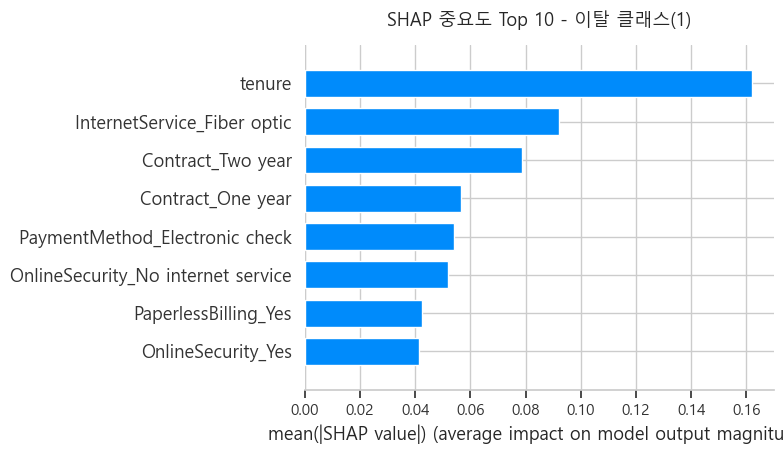

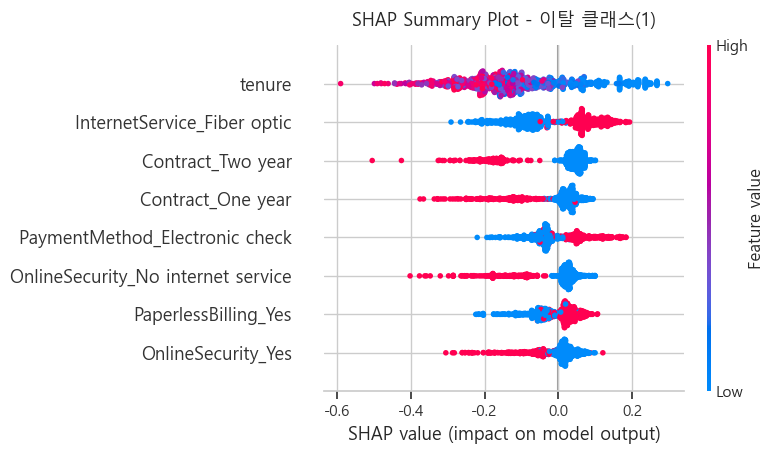

In [8]:
# 성능이 가장 좋았던 모델에 SHAP TreeExplainer 적용
try:
    import shap
except Exception as exc:
    raise ImportError("SHAP 패키지가 필요합니다. 설치 후 다시 실행하세요: uv add shap 또는 pip install shap") from exc


def extract_class1_shap(shap_values):
    """SHAP 버전에 따라 다른 반환 형태에서 이탈 클래스(1)의 SHAP 값을 추출합니다."""
    if isinstance(shap_values, list):
        return shap_values[1]
    values = np.asarray(shap_values)
    if values.ndim == 3:
        return values[:, :, 1]
    return values


def extract_class1_expected_value(explainer):
    expected = explainer.expected_value
    if isinstance(expected, (list, np.ndarray)) and np.asarray(expected).ndim > 0:
        return np.asarray(expected)[1]
    return expected


best_method = results_df.iloc[0]["Method"]
best_info = model_registry[best_method]
best_model = best_info["model"]
best_features = best_info["features"]
X_best_train = best_info["X_train"]
X_best_test = best_info["X_test"]

# 전체 학습 데이터를 모두 쓰면 시간이 오래 걸릴 수 있어 대표 샘플을 사용합니다.
shap_sample = X_best_train.sample(n=min(1000, len(X_best_train)), random_state=42)

explainer = shap.TreeExplainer(best_model)
raw_shap_values = explainer.shap_values(shap_sample)
shap_values_class1 = extract_class1_shap(raw_shap_values)
expected_value_class1 = extract_class1_expected_value(explainer)

shap_importance = pd.DataFrame({
    "변수": shap_sample.columns,
    "mean_abs_SHAP": np.abs(shap_values_class1).mean(axis=0),
}).sort_values("mean_abs_SHAP", ascending=False)

print(f"SHAP 분석 대상 모델: {best_method}")
print(f"SHAP 계산 샘플 수: {len(shap_sample):,}개")
print("이탈(Churn=1)에 대한 SHAP 중요도 Top 10")
display(shap_importance.head(10))

plt.figure()
shap.summary_plot(
    shap_values_class1,
    shap_sample,
    plot_type="bar",
    max_display=10,
    show=False,
)
plt.title("SHAP 중요도 Top 10 - 이탈 클래스(1)", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

shap.summary_plot(
    shap_values_class1,
    shap_sample,
    max_display=10,
    show=False,
)
plt.title("SHAP Summary Plot - 이탈 클래스(1)", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

**[과제]** 써니는 실제로 이탈(Churn=1)로 예측된 고객 한 명을 골라서 Force Plot으로 어떤 변수들이 이탈 예측에 기여했는지 확인해보고자 합니다. AI를 활용해 관련 코드를 작성해보세요.

선택 고객 index: 6314
실제 Churn: 0  |  예측 Churn: 1  |  이탈 확률: 1.000
원본 고객 정보


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6314,Female,0,No,No,6.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,73.85,401.3


Force Plot 해석용 SHAP 기여도 Top 10


,변수,값,SHAP 기여도(이탈=1),기여 방향,|SHAP|
0,tenure,-1.089433,0.149522,이탈 가능성 증가,0.149522
1,InternetService_Fiber optic,1.000000,0.104948,이탈 가능성 증가,0.104948
3,Contract_Two year,0.000000,0.066189,이탈 가능성 증가,0.066189
4,PaperlessBilling_Yes,1.000000,0.061285,이탈 가능성 증가,0.061285
7,OnlineSecurity_No internet service,0.000000,0.051711,이탈 가능성 증가,0.051711
6,Contract_One year,0.000000,0.045275,이탈 가능성 증가,0.045275
5,OnlineSecurity_Yes,0.000000,0.026549,이탈 가능성 증가,0.026549
2,PaymentMethod_Electronic check,0.000000,-0.004960,이탈 가능성 감소,0.004960


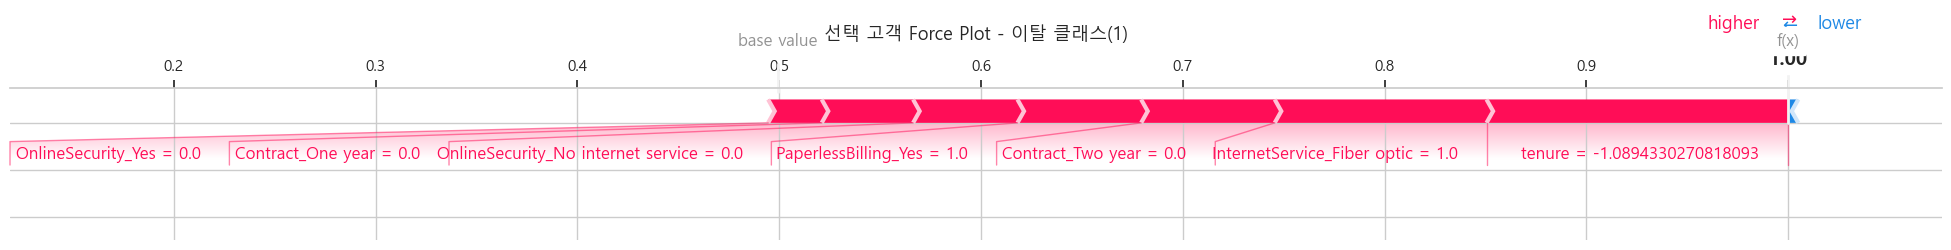

In [9]:
# 이탈(Churn=1)로 예측된 고객 1명에 대한 Force Plot
best_pred = best_model.predict(X_best_test)
best_proba = best_model.predict_proba(X_best_test)[:, 1]

predicted_churn_positions = np.where(best_pred == 1)[0]

if len(predicted_churn_positions) == 0:
    # 이탈 예측이 없으면 이탈 확률이 가장 높은 고객을 대신 선택합니다.
    selected_position = int(np.argmax(best_proba))
    print("이탈로 분류된 고객이 없어, 이탈 확률이 가장 높은 고객을 선택했습니다.")
else:
    selected_position = int(predicted_churn_positions[np.argmax(best_proba[predicted_churn_positions])])

selected_index = X_best_test.index[selected_position]
selected_customer = X_best_test.iloc[[selected_position]]
selected_original = X_test.loc[[selected_index]]

raw_shap_one = explainer.shap_values(selected_customer)
shap_one_class1 = extract_class1_shap(raw_shap_one)
if shap_one_class1.ndim == 2:
    shap_one_class1 = shap_one_class1[0]

contribution_df = pd.DataFrame({
    "변수": selected_customer.columns,
    "값": selected_customer.iloc[0].values,
    "SHAP 기여도(이탈=1)": shap_one_class1,
})
contribution_df["기여 방향"] = np.where(contribution_df["SHAP 기여도(이탈=1)"] >= 0, "이탈 가능성 증가", "이탈 가능성 감소")
contribution_df["|SHAP|"] = contribution_df["SHAP 기여도(이탈=1)"].abs()
contribution_df = contribution_df.sort_values("|SHAP|", ascending=False)

print(f"선택 고객 index: {selected_index}")
print(f"실제 Churn: {y_test.loc[selected_index]}  |  예측 Churn: {best_pred[selected_position]}  |  이탈 확률: {best_proba[selected_position]:.3f}")
print("원본 고객 정보")
display(selected_original)

print("Force Plot 해석용 SHAP 기여도 Top 10")
display(contribution_df.head(10))

shap.force_plot(
    expected_value_class1,
    shap_one_class1,
    selected_customer.iloc[0],
    matplotlib=True,
    show=False,
)
plt.title("선택 고객 Force Plot - 이탈 클래스(1)", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

## 6) 분석 결과 종합 및 활용

**[과제]** 써니는 앞선 변수 선택 결과와 SHAP 분석을 종합해서, 이탈 고객을 막으려면 어떤 마케팅을 해야 할지 궁금합니다. AI와 상의하여 이탈로 예측된 고객들이 어떤 변수 때문에 그렇게 예측됐는지 파악하고 그에 맞는 마케팅 방식을 추천받아 보세요.

이탈로 예측된 고객 수: 520명
이탈 예측 고객군에서 이탈 가능성을 높인 변수 Top 10


,변수,평균 SHAP,평균 |SHAP|
3,Contract_Two year,0.056862,0.061876
1,InternetService_Fiber optic,0.046921,0.095175
6,Contract_One year,0.034580,0.043989
0,tenure,0.027916,0.116396
2,PaymentMethod_Electronic check,0.026632,0.061117
7,OnlineSecurity_No internet service,0.026361,0.046197
5,OnlineSecurity_Yes,0.025638,0.038164
4,PaperlessBilling_Yes,0.020013,0.048083


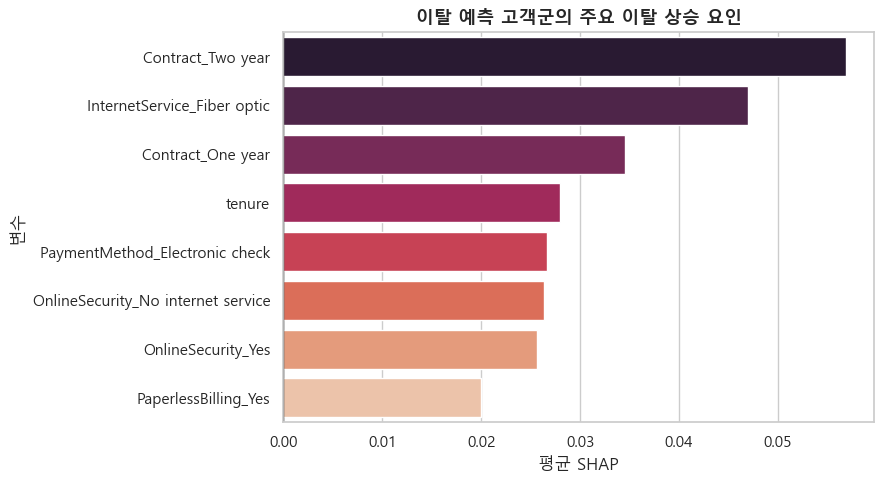

,변수,평균 SHAP,평균 |SHAP|,추천 마케팅 액션
3,Contract_Two year,0.056862,0.061876,"월 단위 계약 고객에게 1년/2년 약정 전환 쿠폰, 약정 할인, 해지 위약금 보전 ..."
1,InternetService_Fiber optic,0.046921,0.095175,"인터넷 품질 불만 가능성이 있으므로 속도/장애 점검, 프리미엄 공유기 또는 품질 보..."
6,Contract_One year,0.034580,0.043989,"월 단위 계약 고객에게 1년/2년 약정 전환 쿠폰, 약정 할인, 해지 위약금 보전 ..."
0,tenure,0.027916,0.116396,"가입 초기 고객에게 온보딩 케어, 사용법 안내, 첫 3개월 만족도 콜백을 제공합니다."
2,PaymentMethod_Electronic check,0.026632,0.061117,전자수표/수동 결제 고객에게 자동이체 전환 리워드와 결제 실패 알림을 제공합니다.
7,OnlineSecurity_No internet service,0.026361,0.046197,보안/백업/기술지원 미가입 고객에게 무료 체험 또는 번들 업셀링으로 서비스 체감 가...
5,OnlineSecurity_Yes,0.025638,0.038164,보안/백업/기술지원 미가입 고객에게 무료 체험 또는 번들 업셀링으로 서비스 체감 가...
4,PaperlessBilling_Yes,0.020013,0.048083,전자 청구 고객에게 요금 변동 알림과 절감 추천 리포트를 제공해 가격 민감도를 낮춥니다.


종합 해석
- 이번 분석에서 최종 해석 대상 모델은 'mRMR (k=8)'입니다.
- mRMR/Boruta로 변수 수를 줄여도 성능이 유지된다면, 마케팅팀은 적은 변수로도 이탈 위험 고객을 설명할 수 있습니다.
- SHAP 평균값이 양수인 변수는 이탈 예측을 밀어 올린 요인입니다. 위 표의 상위 변수부터 캠페인 우선순위를 정하면 됩니다.
- 실행 후 실제 상위 변수명을 확인하고, 요금/계약/서비스품질/지원서비스 중 어느 축이 강한지에 따라 타겟 캠페인을 설계하세요.


In [10]:
# 변수 선택 결과 + SHAP 분석을 종합한 마케팅 제안
predicted_churn_mask = best_pred == 1

if predicted_churn_mask.sum() == 0:
    churn_group = X_best_test.iloc[np.argsort(best_proba)[-min(100, len(best_proba)):]]
    print("이탈로 직접 예측된 고객이 없어, 이탈 확률 상위 고객군을 분석합니다.")
else:
    churn_group = X_best_test.loc[predicted_churn_mask]
    print(f"이탈로 예측된 고객 수: {len(churn_group):,}명")

# 고객군이 너무 크면 속도를 위해 샘플링
churn_group_sample = churn_group.sample(n=min(500, len(churn_group)), random_state=42)
raw_shap_churn_group = explainer.shap_values(churn_group_sample)
shap_churn_group = extract_class1_shap(raw_shap_churn_group)

# 양의 SHAP 평균: 이탈 예측을 높이는 방향의 평균 기여도
positive_driver_df = pd.DataFrame({
    "변수": churn_group_sample.columns,
    "평균 SHAP": shap_churn_group.mean(axis=0),
    "평균 |SHAP|": np.abs(shap_churn_group).mean(axis=0),
}).sort_values("평균 SHAP", ascending=False)

print("이탈 예측 고객군에서 이탈 가능성을 높인 변수 Top 10")
display(positive_driver_df.head(10))

plt.figure(figsize=(9, 5))
sns.barplot(data=positive_driver_df.head(10), x="평균 SHAP", y="변수", palette="rocket")
plt.axvline(0, color="black", linewidth=1)
plt.title("이탈 예측 고객군의 주요 이탈 상승 요인", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


def make_marketing_recommendation(feature):
    text = feature.lower()
    if "contract" in text:
        return "월 단위 계약 고객에게 1년/2년 약정 전환 쿠폰, 약정 할인, 해지 위약금 보전 혜택을 제안합니다."
    if "tenure" in text:
        return "가입 초기 고객에게 온보딩 케어, 사용법 안내, 첫 3개월 만족도 콜백을 제공합니다."
    if "monthlycharges" in text or "totalcharges" in text:
        return "요금 부담이 큰 고객에게 맞춤형 요금제 다운셀링, 결합 할인, 한시적 청구 할인 쿠폰을 제공합니다."
    if "internetservice" in text or "fiber optic" in text:
        return "인터넷 품질 불만 가능성이 있으므로 속도/장애 점검, 프리미엄 공유기 또는 품질 보상 캠페인을 제안합니다."
    if "paymentmethod" in text or "electronic check" in text:
        return "전자수표/수동 결제 고객에게 자동이체 전환 리워드와 결제 실패 알림을 제공합니다."
    if "techsupport" in text or "onlinesecurity" in text or "onlinebackup" in text or "deviceprotection" in text:
        return "보안/백업/기술지원 미가입 고객에게 무료 체험 또는 번들 업셀링으로 서비스 체감 가치를 높입니다."
    if "paperlessbilling" in text:
        return "전자 청구 고객에게 요금 변동 알림과 절감 추천 리포트를 제공해 가격 민감도를 낮춥니다."
    if "seniorcitizen" in text:
        return "고령 고객에게 쉬운 상담 채널, 가족 결합 안내, 방문/전화 지원을 강화합니다."
    return "해당 변수 값이 높은 고객군을 세분화해 맞춤 메시지와 혜택 A/B 테스트를 진행합니다."

recommendation_df = positive_driver_df.head(10).copy()
recommendation_df["추천 마케팅 액션"] = recommendation_df["변수"].apply(make_marketing_recommendation)
display(recommendation_df[["변수", "평균 SHAP", "평균 |SHAP|", "추천 마케팅 액션"]])

print("종합 해석")
print(f"- 이번 분석에서 최종 해석 대상 모델은 '{best_method}'입니다.")
print("- mRMR/Boruta로 변수 수를 줄여도 성능이 유지된다면, 마케팅팀은 적은 변수로도 이탈 위험 고객을 설명할 수 있습니다.")
print("- SHAP 평균값이 양수인 변수는 이탈 예측을 밀어 올린 요인입니다. 위 표의 상위 변수부터 캠페인 우선순위를 정하면 됩니다.")
print("- 실행 후 실제 상위 변수명을 확인하고, 요금/계약/서비스품질/지원서비스 중 어느 축이 강한지에 따라 타겟 캠페인을 설계하세요.")

## 7) 추가 실험: Feature Selection 4종 x Boosting 모델 3종 비교

- Feature Selection 방법: 전체 변수, mRMR, Boruta, BorutaShap
- 모델: LightGBM, XGBoost, CatBoost
- 하이퍼파라미터 최적화: Optuna, 각 조합별 `n_trials <= 30`
- Boruta/BorutaShap의 tree estimator는 Random Forest가 아니라 각 비교 모델의 estimator를 사용합니다.

In [25]:
# 추가 실험용 패키지 및 전역 설정
# 필요 패키지가 없다면 아래 명령을 노트북/터미널에서 먼저 실행하세요.
# !uv add optuna lightgbm xgboost catboost borutashap boruta mrmr-selection

import sys
import time
from collections import defaultdict
import numpy as np
from sklearn.metrics import roc_auc_score

missing_packages = []

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except Exception:
    missing_packages.append("optuna")

try:
    from lightgbm import LGBMClassifier
except Exception:
    missing_packages.append("lightgbm")

try:
    from xgboost import XGBClassifier
except Exception:
    missing_packages.append("xgboost")

try:
    from catboost import CatBoostClassifier
except Exception:
    missing_packages.append("catboost")

try:
    from boruta import BorutaPy
except Exception:
    missing_packages.append("boruta")

try:
    # BorutaShap 1.0.x는 NumPy/SciPy 구버전 API를 사용합니다.
    # 최신 NumPy 2.x: np.NaN 제거 -> np.nan alias 추가
    # 최신 SciPy: scipy.stats.binom_test 제거 -> binomtest 래퍼 추가
    import scipy.stats as scipy_stats

    if not hasattr(np, "NaN"):
        np.NaN = np.nan

    if hasattr(scipy_stats, "binomtest"):
        def _binom_test(x, n=None, p=0.5, alternative="two-sided"):
            # 구 binom_test는 float 형태의 정수값도 허용했지만, 신 binomtest는 int만 허용합니다.
            return scipy_stats.binomtest(k=int(round(float(x))), n=int(round(float(n))), p=p, alternative=alternative).pvalue

        # 기존에 잘못된 래퍼가 남아 있어도 항상 안전 래퍼로 덮어씁니다.
        scipy_stats.binom_test = _binom_test

    from BorutaShap import BorutaShap
    # BorutaShap.py는 from scipy.stats import binom_test로 전역 함수를 바인딩하므로
    # 이미 import된 모듈 내부 전역도 직접 교체해야 합니다.
    if "BorutaShap" in sys.modules and hasattr(scipy_stats, "binom_test"):
        sys.modules["BorutaShap"].binom_test = scipy_stats.binom_test
except Exception as exc:
    print(f"BorutaShap import 실패: {exc}")
    missing_packages.append("borutashap")

if missing_packages:
    raise ImportError(
        "추가 실험에 필요한 패키지가 없습니다: "
        + ", ".join(sorted(set(missing_packages)))
        + "\n설치 예시: uv add optuna lightgbm xgboost catboost borutashap boruta mrmr-selection"
    )

N_TRIALS = 50
RANDOM_STATE = 42
FS_MAX_ITER = 50
BORUTASHAP_TRIALS = 50

print(f"Optuna trials per model/feature-set: {N_TRIALS}")
print(f"Boruta max_iter: {FS_MAX_ITER}")
print(f"BorutaShap n_trials: {BORUTASHAP_TRIALS}")

Optuna trials per model/feature-set: 50
Boruta max_iter: 50
BorutaShap n_trials: 50


In [ ]:
# 모델 팩토리, Optuna 튜닝 함수, 모델별 feature selection 함수


def get_pos_weight(y_series):
    counts = pd.Series(y_series).value_counts()
    return counts.get(0, 1) / max(counts.get(1, 1), 1)


def make_selector_estimator(model_name, y_series):
    """Boruta/BorutaShap 변수 선택에 사용할 모델별 tree estimator."""
    pos_weight = get_pos_weight(y_series)
    if model_name == "LightGBM":
        return LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            # BorutaPy의 n_estimators="auto" 계산은 max_depth=-1에서 음수가 될 수 있습니다.
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    if model_name == "XGBoost":
        return XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            scale_pos_weight=pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )
    if model_name == "CatBoost":
        return CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=5,
            loss_function="Logloss",
            eval_metric="F1",
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        )
    raise ValueError(f"지원하지 않는 모델명: {model_name}")


def make_tuned_model(model_name, params, y_series):
    """Optuna가 찾은 파라미터로 최종 학습 모델 생성."""
    pos_weight = get_pos_weight(y_series)
    if model_name == "LightGBM":
        return LGBMClassifier(
            objective="binary",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
            **params,
        )
    if model_name == "XGBoost":
        return XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
            **params,
        )
    if model_name == "CatBoost":
        return CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="F1",
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            **params,
        )
    raise ValueError(f"지원하지 않는 모델명: {model_name}")


def suggest_params(trial, model_name):
    """모델별 Optuna search space."""
    if model_name == "LightGBM":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 600),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 96),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
            "subsample": trial.suggest_float("subsample", 0.65, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 5.0, log=True),
        }
    if model_name == "XGBoost":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 600),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 8),
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
            "subsample": trial.suggest_float("subsample", 0.65, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 5.0, log=True),
        }
    if model_name == "CatBoost":
        return {
            "iterations": trial.suggest_int("iterations", 100, 600),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "depth": trial.suggest_int("depth", 3, 8),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            "random_strength": trial.suggest_float("random_strength", 0.0, 5.0),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
            "border_count": trial.suggest_int("border_count", 32, 255),
        }
    raise ValueError(f"지원하지 않는 모델명: {model_name}")


def tune_and_evaluate(model_name, fs_name, features, X_tr_full, X_te, y_tr_full, y_te, n_trials=N_TRIALS):
    """Validation F1을 Optuna objective로 튜닝한 뒤, full train 재학습 후 test 평가."""
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr_full[features],
        y_tr_full,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_tr_full,
    )

    def objective(trial):
        params = suggest_params(trial, model_name)
        model = make_tuned_model(model_name, params, y_tr)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        return f1_score(y_val, pred, zero_division=0)

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False, n_jobs=-1)

    best_model = make_tuned_model(model_name, study.best_params, y_tr_full)
    best_model.fit(X_tr_full[features], y_tr_full)

    pred = best_model.predict(X_te[features])
    proba = best_model.predict_proba(X_te[features])[:, 1]

    metrics = {
        "Feature Selection": fs_name,
        "Model": model_name,
        "변수 수": len(features),
        "Best Valid F1": study.best_value,
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred, zero_division=0),
        "Recall": recall_score(y_te, pred, zero_division=0),
        "F1-score": f1_score(y_te, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_te, proba),
        "Best Params": study.best_params,
    }
    return best_model, pred, proba, metrics


def select_by_mrmr_if_needed(X_df, y_series, k=None):
    """기존 selected_mrmr가 없을 때 재계산합니다."""
    if "selected_mrmr" in globals() and len(selected_mrmr) > 0:
        return list(selected_mrmr)

    if k is None:
        k = min(12, X_df.shape[1])
    try:
        from mrmr import mrmr_classif
        return list(mrmr_classif(X=X_df, y=y_series, K=k))
    except Exception:
        mi = mutual_info_classif(X_df, y_series, random_state=RANDOM_STATE)
        return pd.Series(mi, index=X_df.columns).sort_values(ascending=False).head(k).index.tolist()


def select_by_model_importance(model_name, X_df, y_series, top_n=None):
    """Boruta 계열이 실패할 때 사용하는 모델별 feature importance 대체 선택."""
    if top_n is None:
        top_n = min(12, X_df.shape[1])
    estimator = make_selector_estimator(model_name, y_series)
    estimator.fit(X_df, y_series)
    importances = pd.Series(estimator.feature_importances_, index=X_df.columns).sort_values(ascending=False)
    selected = importances.head(top_n).index.tolist()
    return selected, importances


def select_by_boruta(model_name, X_df, y_series):
    estimator = make_selector_estimator(model_name, y_series)
    try:
        selector = BorutaPy(
            estimator=estimator,
            # auto는 LightGBM max_depth=-1 등에서 음수 n_estimators를 만들 수 있어 고정값을 사용합니다.
            n_estimators=250,
            max_iter=FS_MAX_ITER,
            perc=90,
            random_state=RANDOM_STATE,
            verbose=0,
        )
        selector.fit(X_df.values, y_series.values)

        confirmed = X_df.columns[selector.support_].tolist()
        tentative = X_df.columns[selector.support_weak_].tolist()
        selected = confirmed if len(confirmed) >= 3 else confirmed + tentative
        meta = {"확정": confirmed, "미정": tentative, "fallback": False}
    except Exception as exc:
        selected, importances = select_by_model_importance(model_name, X_df, y_series)
        meta = {
            "확정": selected,
            "미정": [],
            "fallback": True,
            "fallback_reason": str(exc),
            "importance_top": importances.head(10).to_dict(),
        }
        print(f"BorutaPy 실패 → {model_name} feature_importances_ 상위 변수로 대체합니다: {exc}")

    if len(selected) == 0:
        selected, importances = select_by_model_importance(model_name, X_df, y_series)
        meta.update({"fallback": True, "importance_top": importances.head(10).to_dict()})

    return list(dict.fromkeys(selected)), meta


def ensure_borutashap_compatibility():
    """BorutaShap 구버전이 최신 NumPy/SciPy에서도 동작하도록 런타임 alias를 보장합니다."""
    import sys

    if not hasattr(np, "NaN"):
        np.NaN = np.nan
    try:
        import scipy.stats as scipy_stats
        if hasattr(scipy_stats, "binomtest"):
            def _binom_test(x, n=None, p=0.5, alternative="two-sided"):
                # 구 binom_test는 float 형태의 정수값도 허용했지만, 신 binomtest는 int만 허용합니다.
                return scipy_stats.binomtest(k=int(round(float(x))), n=int(round(float(n))), p=p, alternative=alternative).pvalue

            # 기존에 잘못된 래퍼가 남아 있어도 항상 안전 래퍼로 덮어씁니다.
            scipy_stats.binom_test = _binom_test

        # BorutaShap.py 내부에 이미 바인딩된 binom_test도 직접 교체합니다.
        if "BorutaShap" in sys.modules and hasattr(scipy_stats, "binom_test"):
            sys.modules["BorutaShap"].binom_test = scipy_stats.binom_test
    except Exception:
        pass


def select_by_borutashap(model_name, X_df, y_series):
    ensure_borutashap_compatibility()
    estimator = make_selector_estimator(model_name, y_series)
    try:
        selector = BorutaShap(
            model=estimator,
            importance_measure="shap",
            classification=True,
        )
        selector.fit(
            X=X_df,
            y=y_series,
            n_trials=BORUTASHAP_TRIALS,
            random_state=RANDOM_STATE,
            sample=False,
            train_or_test="test",
            normalize=True,
            verbose=False,
        )

        try:
            selected = selector.Subset().columns.tolist()
        except Exception:
            selected = []

        if not selected and hasattr(selector, "accepted"):
            selected = list(selector.accepted)

        meta = {
            "accepted": list(getattr(selector, "accepted", [])),
            "tentative": list(getattr(selector, "tentative", [])),
            "rejected": list(getattr(selector, "rejected", [])),
            "fallback": False,
        }
    except Exception as exc:
        selected, importances = select_by_model_importance(model_name, X_df, y_series)
        meta = {
            "accepted": selected,
            "tentative": [],
            "rejected": [],
            "fallback": True,
            "fallback_reason": str(exc),
            "importance_top": importances.head(10).to_dict(),
        }
        print(f"BorutaShap 실패 → {model_name} feature_importances_ 상위 변수로 대체합니다: {exc}")

    if len(selected) == 0:
        selected, importances = select_by_model_importance(model_name, X_df, y_series)
        meta.update({"fallback": True, "importance_top": importances.head(10).to_dict()})

    return list(dict.fromkeys(selected)), meta


BOOSTING_MODELS = ["LightGBM", "XGBoost", "CatBoost"]
FEATURE_SELECTION_METHODS = ["전체 변수", "mRMR", "Boruta", "BorutaShap"]

In [27]:
# 4가지 Feature Selection x 3가지 Boosting 모델 비교 실행
# 주의: 12개 조합 x Optuna 30회 튜닝이므로 실행 시간이 꽤 걸릴 수 있습니다.

fs_features = defaultdict(dict)
fs_details = defaultdict(dict)
boosting_results = []
boosting_model_registry = {}

all_features = X_train_processed.columns.tolist()
mrmr_features = select_by_mrmr_if_needed(X_train_processed, y_train, k=min(12, X_train_processed.shape[1]))

for model_name in BOOSTING_MODELS:
    print("\n" + "=" * 90)
    print(f"[{model_name}] Feature Selection 시작")
    print("=" * 90)

    fs_features[model_name]["전체 변수"] = all_features
    fs_details[model_name]["전체 변수"] = {"선택 방식": "전처리 후 전체 입력 변수 사용"}

    fs_features[model_name]["mRMR"] = mrmr_features
    fs_details[model_name]["mRMR"] = {"선택 방식": "mRMR 분류 기준 선택", "선택 변수": mrmr_features}

    boruta_features, boruta_meta = select_by_boruta(model_name, X_train_processed, y_train)
    fs_features[model_name]["Boruta"] = boruta_features
    fs_details[model_name]["Boruta"] = boruta_meta
    print(f"Boruta 선택 변수 {len(boruta_features)}개")

    borutashap_features, borutashap_meta = select_by_borutashap(model_name, X_train_processed, y_train)
    fs_features[model_name]["BorutaShap"] = borutashap_features
    fs_details[model_name]["BorutaShap"] = borutashap_meta
    print(f"BorutaShap 선택 변수 {len(borutashap_features)}개")

    for fs_name in FEATURE_SELECTION_METHODS:
        features = fs_features[model_name][fs_name]
        print(f"\n튜닝/평가: {fs_name} x {model_name} | 변수 {len(features)}개")
        start = time.time()

        tuned_model, pred, proba, metrics = tune_and_evaluate(
            model_name=model_name,
            fs_name=fs_name,
            features=features,
            X_tr_full=X_train_processed,
            X_te=X_test_processed,
            y_tr_full=y_train,
            y_te=y_test,
            n_trials=N_TRIALS,
        )
        metrics["Elapsed sec"] = time.time() - start
        boosting_results.append(metrics)
        boosting_model_registry[(fs_name, model_name)] = {
            "model": tuned_model,
            "features": features,
            "pred": pred,
            "proba": proba,
        }
        print(
            f"완료: F1={metrics['F1-score']:.3f}, "
            f"Recall={metrics['Recall']:.3f}, ROC-AUC={metrics['ROC-AUC']:.3f}, "
            f"소요={metrics['Elapsed sec']:.1f}s"
        )

boosting_results_df = pd.DataFrame(boosting_results).sort_values(
    ["F1-score", "Recall", "ROC-AUC"], ascending=False
).reset_index(drop=True)

print("\n전체 조합 성능 순위")
display(
    boosting_results_df.drop(columns=["Best Params"]).style.format({
        "Best Valid F1": "{:.3f}",
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1-score": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "Elapsed sec": "{:.1f}",
    }).background_gradient(subset=["F1-score", "Recall", "ROC-AUC"], cmap="YlGn")
)


[LightGBM] Feature Selection 시작
Boruta 선택 변수 3개


100%|██████████| 50/50 [05:40<00:00,  6.82s/it]


BorutaShap 선택 변수 6개

튜닝/평가: 전체 변수 x LightGBM | 변수 30개
완료: F1=0.634, Recall=0.767, ROC-AUC=0.837, 소요=34.8s

튜닝/평가: mRMR x LightGBM | 변수 8개
완료: F1=0.615, Recall=0.781, ROC-AUC=0.835, 소요=17.9s

튜닝/평가: Boruta x LightGBM | 변수 3개
완료: F1=0.585, Recall=0.717, ROC-AUC=0.801, 소요=22.7s

튜닝/평가: BorutaShap x LightGBM | 변수 6개
완료: F1=0.630, Recall=0.789, ROC-AUC=0.835, 소요=11.9s

[XGBoost] Feature Selection 시작
Boruta 선택 변수 19개


100%|██████████| 50/50 [02:50<00:00,  3.41s/it]


BorutaShap 선택 변수 8개

튜닝/평가: 전체 변수 x XGBoost | 변수 30개
완료: F1=0.634, Recall=0.797, ROC-AUC=0.844, 소요=23.8s

튜닝/평가: mRMR x XGBoost | 변수 8개
완료: F1=0.619, Recall=0.805, ROC-AUC=0.839, 소요=16.8s

튜닝/평가: Boruta x XGBoost | 변수 19개
완료: F1=0.631, Recall=0.778, ROC-AUC=0.836, 소요=20.7s

튜닝/평가: BorutaShap x XGBoost | 변수 8개
완료: F1=0.626, Recall=0.799, ROC-AUC=0.838, 소요=17.3s

[CatBoost] Feature Selection 시작
BorutaPy 실패 → CatBoost feature_importances_ 상위 변수로 대체합니다: Please check your X and y variable. The provided estimator cannot be fitted to your data.
only one of the parameters random_seed, random_state should be initialized.
Boruta 선택 변수 12개


  4%|▍         | 2/50 [00:08<03:24,  4.25s/it]


KeyboardInterrupt: 

,Feature Selection,Model,변수 수,Accuracy,Precision,Recall,F1-score,ROC-AUC,Best Valid F1,Elapsed sec
0,전체 변수,LightGBM,30,0.764,0.539,0.767,0.634,0.837,0.639,22.0
1,BorutaShap,LightGBM,9,0.754,0.525,0.794,0.632,0.837,0.639,10.3
2,Boruta,XGBoost,19,0.758,0.530,0.778,0.631,0.836,0.639,10.0
3,전체 변수,XGBoost,30,0.756,0.527,0.778,0.629,0.842,0.647,13.5
4,전체 변수,CatBoost,30,0.747,0.515,0.797,0.625,0.844,0.639,33.8
5,Boruta,CatBoost,12,0.745,0.513,0.783,0.620,0.842,0.631,47.6
6,mRMR,XGBoost,8,0.738,0.504,0.802,0.619,0.838,0.634,7.5
7,BorutaShap,CatBoost,8,0.740,0.506,0.794,0.618,0.837,0.636,26.0
8,mRMR,CatBoost,8,0.741,0.508,0.789,0.618,0.838,0.642,22.6
9,mRMR,LightGBM,8,0.741,0.508,0.789,0.618,0.836,0.638,12.6


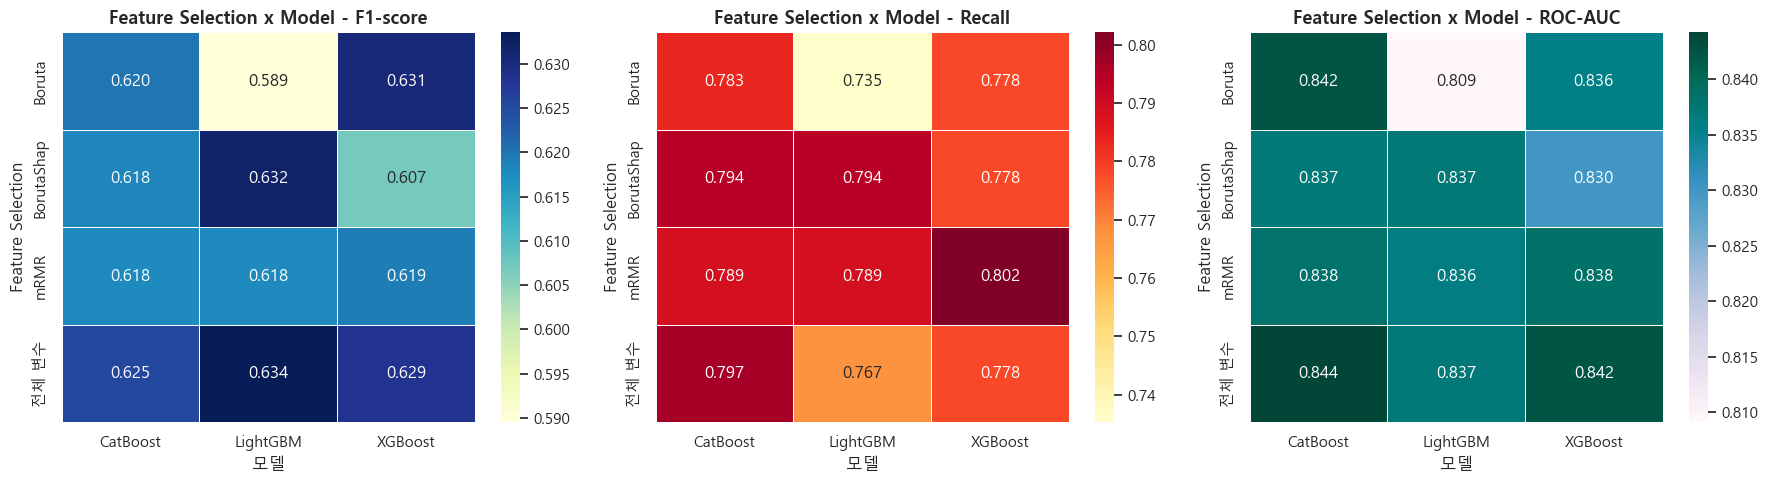

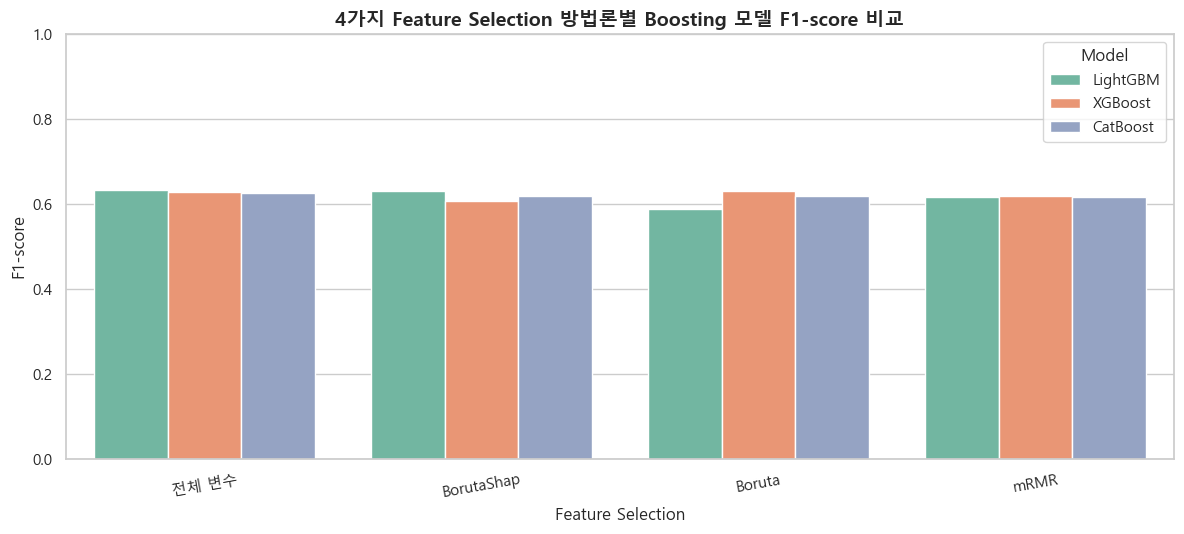

Feature Selection 방법별 최고 모델


,Feature Selection,Model,변수 수,Accuracy,Precision,Recall,F1-score,ROC-AUC,Best Valid F1,Elapsed sec
0,Boruta,XGBoost,19,0.758,0.530,0.778,0.631,0.836,0.639,10.0
1,BorutaShap,LightGBM,9,0.754,0.525,0.794,0.632,0.837,0.639,10.3
2,mRMR,XGBoost,8,0.738,0.504,0.802,0.619,0.838,0.634,7.5
3,전체 변수,LightGBM,30,0.764,0.539,0.767,0.634,0.837,0.639,22.0


모델별 최고 Feature Selection 방법


,Feature Selection,Model,변수 수,Accuracy,Precision,Recall,F1-score,ROC-AUC,Best Valid F1,Elapsed sec
0,전체 변수,CatBoost,30,0.747,0.515,0.797,0.625,0.844,0.639,33.8
1,전체 변수,LightGBM,30,0.764,0.539,0.767,0.634,0.837,0.639,22.0
2,Boruta,XGBoost,19,0.758,0.530,0.778,0.631,0.836,0.639,10.0


최종 추천 조합
- Feature Selection: 전체 변수
- Model: LightGBM
- 변수 수: 30개
- Test F1-score: 0.634
- Test Recall: 0.767
- Test ROC-AUC: 0.837
- Best Params:


,value
n_estimators,454.000000
learning_rate,0.010636
num_leaves,94.000000
max_depth,9.000000
min_child_samples,25.000000
subsample,0.713639
colsample_bytree,0.714192
reg_alpha,0.002689
reg_lambda,0.029229


해석 가이드
- 이탈 예측에서는 Accuracy보다 F1-score와 Recall을 함께 보는 것이 중요합니다.
- Recall이 높은 조합은 실제 이탈 고객을 놓칠 위험이 작고, Precision이 높은 조합은 캠페인 비용 낭비가 적습니다.
- Boruta/BorutaShap이 전체 변수 대비 비슷한 성능을 내면서 변수 수를 줄이면, 설명력과 운영 효율성이 좋아진 선택입니다.
- 최종 모델을 SHAP으로 해석하려면 best_boosting_model_info['model']과 best_boosting_model_info['features']를 사용하면 됩니다.


In [ ]:
# 최종 비교 요약 및 해석

summary_cols = [
    "Feature Selection",
    "Model",
    "변수 수",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "Best Valid F1",
    "Elapsed sec",
]

final_boosting_summary = boosting_results_df[summary_cols].copy()
display(
    final_boosting_summary.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1-score": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "Best Valid F1": "{:.3f}",
        "Elapsed sec": "{:.1f}",
    })
)

# Feature Selection x Model 성능 매트릭스
f1_pivot = final_boosting_summary.pivot(index="Feature Selection", columns="Model", values="F1-score")
recall_pivot = final_boosting_summary.pivot(index="Feature Selection", columns="Model", values="Recall")
auc_pivot = final_boosting_summary.pivot(index="Feature Selection", columns="Model", values="ROC-AUC")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pivot, title, cmap in zip(
    axes,
    [f1_pivot, recall_pivot, auc_pivot],
    ["F1-score", "Recall", "ROC-AUC"],
    ["YlGnBu", "YlOrRd", "PuBuGn"],
):
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, linewidths=0.5, ax=ax)
    ax.set_title(f"Feature Selection x Model - {title}", fontsize=13, fontweight="bold")
    ax.set_xlabel("모델")
    ax.set_ylabel("Feature Selection")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5.5))
sns.barplot(
    data=final_boosting_summary,
    x="Feature Selection",
    y="F1-score",
    hue="Model",
)
plt.title("4가지 Feature Selection 방법론별 Boosting 모델 F1-score 비교", fontsize=14, fontweight="bold")
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

best_by_fs = (
    final_boosting_summary.sort_values(["Feature Selection", "F1-score", "Recall", "ROC-AUC"], ascending=[True, False, False, False])
    .groupby("Feature Selection")
    .head(1)
    .reset_index(drop=True)
)

best_by_model = (
    final_boosting_summary.sort_values(["Model", "F1-score", "Recall", "ROC-AUC"], ascending=[True, False, False, False])
    .groupby("Model")
    .head(1)
    .reset_index(drop=True)
)

print("Feature Selection 방법별 최고 모델")
display(best_by_fs.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-score": "{:.3f}",
    "ROC-AUC": "{:.3f}",
    "Best Valid F1": "{:.3f}",
    "Elapsed sec": "{:.1f}",
}))

print("모델별 최고 Feature Selection 방법")
display(best_by_model.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-score": "{:.3f}",
    "ROC-AUC": "{:.3f}",
    "Best Valid F1": "{:.3f}",
    "Elapsed sec": "{:.1f}",
}))

best_row = boosting_results_df.iloc[0]
best_key = (best_row["Feature Selection"], best_row["Model"])
best_boosting_model_info = boosting_model_registry[best_key]

print("최종 추천 조합")
print(f"- Feature Selection: {best_row['Feature Selection']}")
print(f"- Model: {best_row['Model']}")
print(f"- 변수 수: {int(best_row['변수 수'])}개")
print(f"- Test F1-score: {best_row['F1-score']:.3f}")
print(f"- Test Recall: {best_row['Recall']:.3f}")
print(f"- Test ROC-AUC: {best_row['ROC-AUC']:.3f}")
print("- Best Params:")
display(pd.DataFrame([best_row["Best Params"]]).T.rename(columns={0: "value"}))

print("해석 가이드")
print("- 이탈 예측에서는 Accuracy보다 F1-score와 Recall을 함께 보는 것이 중요합니다.")
print("- Recall이 높은 조합은 실제 이탈 고객을 놓칠 위험이 작고, Precision이 높은 조합은 캠페인 비용 낭비가 적습니다.")
print("- Boruta/BorutaShap이 전체 변수 대비 비슷한 성능을 내면서 변수 수를 줄이면, 설명력과 운영 효율성이 좋아진 선택입니다.")
print("- 최종 모델을 SHAP으로 해석하려면 best_boosting_model_info['model']과 best_boosting_model_info['features']를 사용하면 됩니다.")

## 8) 최적화 추가 실험: CV, Threshold Tuning, PR-AUC, CatBoost Raw Categorical

앞선 실험에서 변수축소가 단일 split 기준 성능 향상으로 바로 이어지지 않았으므로, 아래 5가지를 반영해 더 공정한 추가 실험을 수행합니다.

1. `StratifiedKFold` 5-fold 평균 성능 비교
2. Fold 내부에서 threshold를 튜닝해 이탈 클래스 F1/Recall 개선
3. CatBoost는 one-hot 데이터뿐 아니라 원본 categorical feature를 직접 사용
4. Feature selection은 각 fold의 train 데이터 안에서만 수행해 데이터 누수 방지
5. `PR-AUC`, `Recall@Top-K` 등 마케팅 관점 지표 추가

In [28]:
# 최적화 추가 실험용 유틸리티
from sklearn.base import clone
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold

OPT_CV_SPLITS = 5
OPTUNA_TRIALS_CV = 10          # 실행 시간을 고려한 CV 내부 Optuna trial 수. 필요하면 30까지 늘려도 됩니다.
MRMR_K_CV = 10
BORUTA_MAX_ITER_CV = 15
BORUTASHAP_TRIALS_CV = 10
TOP_K_RATE = 0.20              # 마케팅 캠페인 대상 상위 20% 고객 기준 Recall

OPT_MODELS = ["LightGBM", "XGBoost", "CatBoostRaw"]
OPT_FEATURE_SELECTIONS = ["전체 변수", "mRMR", "Boruta", "BorutaShap"]


def make_fold_preprocessor():
    try:
        fold_encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
    except TypeError:
        fold_encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", fold_encoder),
            ]), categorical_features),
        ],
        remainder="drop",
    )


def preprocess_fold(X_fit_raw, X_transform_raw):
    fold_preprocessor = make_fold_preprocessor()
    X_fit_array = fold_preprocessor.fit_transform(X_fit_raw)
    X_transform_array = fold_preprocessor.transform(X_transform_raw)
    fold_feature_names = [
        name.replace("num__", "").replace("cat__", "")
        for name in fold_preprocessor.get_feature_names_out()
    ]
    X_fit_processed = pd.DataFrame(X_fit_array, columns=fold_feature_names, index=X_fit_raw.index)
    X_transform_processed = pd.DataFrame(X_transform_array, columns=fold_feature_names, index=X_transform_raw.index)
    return X_fit_processed, X_transform_processed


def encoded_to_raw_features(encoded_features):
    raw_features = []
    for feature in encoded_features:
        if feature in numeric_features:
            raw_features.append(feature)
            continue
        matched = None
        for cat_col in categorical_features:
            if feature == cat_col or feature.startswith(f"{cat_col}_"):
                matched = cat_col
                break
        if matched is not None:
            raw_features.append(matched)
    return list(dict.fromkeys(raw_features))


def prepare_catboost_raw(X_fit_raw, X_transform_raw, selected_raw_features):
    selected_raw_features = list(dict.fromkeys(selected_raw_features))
    X_fit_cb = X_fit_raw[selected_raw_features].copy()
    X_transform_cb = X_transform_raw[selected_raw_features].copy()

    selected_num = [col for col in selected_raw_features if col in numeric_features]
    selected_cat = [col for col in selected_raw_features if col in categorical_features]

    for col in selected_num:
        median_value = X_fit_cb[col].median()
        X_fit_cb[col] = X_fit_cb[col].fillna(median_value)
        X_transform_cb[col] = X_transform_cb[col].fillna(median_value)

    for col in selected_cat:
        X_fit_cb[col] = X_fit_cb[col].fillna("Missing").astype(str)
        X_transform_cb[col] = X_transform_cb[col].fillna("Missing").astype(str)

    cat_feature_indices = [X_fit_cb.columns.get_loc(col) for col in selected_cat]
    return X_fit_cb, X_transform_cb, cat_feature_indices


def make_fast_selector_estimator(model_name, y_series):
    base_name = "CatBoost" if model_name == "CatBoostRaw" else model_name
    pos_weight = get_pos_weight(y_series)
    if base_name == "LightGBM":
        return LGBMClassifier(
            n_estimators=150,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    if base_name == "XGBoost":
        return XGBClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            scale_pos_weight=pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )
    if base_name == "CatBoost":
        return CatBoostClassifier(
            iterations=150,
            learning_rate=0.05,
            depth=5,
            loss_function="Logloss",
            eval_metric="F1",
            auto_class_weights="Balanced",
            random_state=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        )
    raise ValueError(f"지원하지 않는 모델명: {model_name}")


def select_mrmr_cv(X_df, y_series, k=MRMR_K_CV):
    k = min(k, X_df.shape[1])
    try:
        from mrmr import mrmr_classif
        selected = list(mrmr_classif(X=X_df, y=y_series, K=k))
    except Exception:
        mi = mutual_info_classif(X_df, y_series, random_state=RANDOM_STATE)
        selected = pd.Series(mi, index=X_df.columns).sort_values(ascending=False).head(k).index.tolist()
    return selected


def select_by_boruta_cv(model_name, X_df, y_series):
    estimator = make_fast_selector_estimator(model_name, y_series)
    try:
        selector = BorutaPy(
            estimator=estimator,
            n_estimators=150,
            max_iter=BORUTA_MAX_ITER_CV,
            perc=90,
            random_state=RANDOM_STATE,
            verbose=0,
        )
        selector.fit(X_df.values, y_series.values)
        confirmed = X_df.columns[selector.support_].tolist()
        tentative = X_df.columns[selector.support_weak_].tolist()
        selected = confirmed if len(confirmed) >= 3 else confirmed + tentative
        if not selected:
            raise RuntimeError("Boruta selected no features")
        return list(dict.fromkeys(selected)), {"fallback": False, "confirmed": confirmed, "tentative": tentative}
    except Exception as exc:
        estimator.fit(X_df, y_series)
        selected = pd.Series(estimator.feature_importances_, index=X_df.columns).sort_values(ascending=False).head(MRMR_K_CV).index.tolist()
        return selected, {"fallback": True, "reason": str(exc)}


def select_by_borutashap_cv(model_name, X_df, y_series):
    ensure_borutashap_compatibility()
    estimator = make_fast_selector_estimator(model_name, y_series)
    try:
        selector = BorutaShap(model=estimator, importance_measure="shap", classification=True)
        selector.fit(
            X=X_df,
            y=y_series,
            n_trials=BORUTASHAP_TRIALS_CV,
            random_state=RANDOM_STATE,
            sample=False,
            train_or_test="train",
            normalize=True,
            verbose=False,
        )
        try:
            selected = selector.Subset().columns.tolist()
        except Exception:
            selected = list(getattr(selector, "accepted", []))
        if not selected:
            raise RuntimeError("BorutaShap selected no features")
        return list(dict.fromkeys(selected)), {"fallback": False, "accepted": list(getattr(selector, "accepted", []))}
    except Exception as exc:
        estimator.fit(X_df, y_series)
        selected = pd.Series(estimator.feature_importances_, index=X_df.columns).sort_values(ascending=False).head(MRMR_K_CV).index.tolist()
        return selected, {"fallback": True, "reason": str(exc)}


def select_features_inside_fold(fs_name, model_name, X_train_fold_processed, y_train_fold):
    if fs_name == "전체 변수":
        return X_train_fold_processed.columns.tolist(), {"fallback": False}
    if fs_name == "mRMR":
        selected = select_mrmr_cv(X_train_fold_processed, y_train_fold)
        return selected, {"fallback": False}
    if fs_name == "Boruta":
        return select_by_boruta_cv(model_name, X_train_fold_processed, y_train_fold)
    if fs_name == "BorutaShap":
        return select_by_borutashap_cv(model_name, X_train_fold_processed, y_train_fold)
    raise ValueError(f"지원하지 않는 feature selection: {fs_name}")


def find_best_threshold(y_true, proba, metric="f1"):
    thresholds = np.linspace(0.05, 0.95, 91)
    rows = []
    for threshold in thresholds:
        pred = (proba >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
        })
    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.sort_values([metric, "recall"], ascending=False).iloc[0]
    return float(best_row["threshold"]), threshold_df


def recall_at_top_k(y_true, proba, top_rate=TOP_K_RATE):
    y_true_arr = np.asarray(y_true)
    proba_arr = np.asarray(proba)
    top_n = max(1, int(np.ceil(len(proba_arr) * top_rate)))
    top_idx = np.argsort(proba_arr)[::-1][:top_n]
    positives = max(1, int(y_true_arr.sum()))
    return float(y_true_arr[top_idx].sum() / positives)


def make_optimized_model(model_name, params, y_series):
    if model_name == "CatBoostRaw":
        return make_tuned_model("CatBoost", params, y_series)
    return make_tuned_model(model_name, params, y_series)


def fit_optimized_model(model, model_name, X_fit, y_fit, cat_features=None):
    if model_name == "CatBoostRaw":
        model.fit(X_fit, y_fit, cat_features=cat_features)
    else:
        model.fit(X_fit, y_fit)
    return model


def tune_threshold_model(model_name, X_train_model, y_train_model, cat_features=None, n_trials=OPTUNA_TRIALS_CV):
    X_inner_train, X_inner_valid, y_inner_train, y_inner_valid = train_test_split(
        X_train_model,
        y_train_model,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_train_model,
    )

    def objective(trial):
        base_model_name = "CatBoost" if model_name == "CatBoostRaw" else model_name
        params = suggest_params(trial, base_model_name)
        model = make_optimized_model(model_name, params, y_inner_train)
        fit_optimized_model(model, model_name, X_inner_train, y_inner_train, cat_features=cat_features)
        proba = model.predict_proba(X_inner_valid)[:, 1]
        threshold, _ = find_best_threshold(y_inner_valid, proba, metric="f1")
        pred = (proba >= threshold).astype(int)
        return f1_score(y_inner_valid, pred, zero_division=0)

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    base_model_name = "CatBoost" if model_name == "CatBoostRaw" else model_name
    threshold_model = make_optimized_model(model_name, study.best_params, y_inner_train)
    fit_optimized_model(threshold_model, model_name, X_inner_train, y_inner_train, cat_features=cat_features)
    inner_proba = threshold_model.predict_proba(X_inner_valid)[:, 1]
    best_threshold, threshold_df = find_best_threshold(y_inner_valid, inner_proba, metric="f1")

    final_model = make_optimized_model(model_name, study.best_params, y_train_model)
    fit_optimized_model(final_model, model_name, X_train_model, y_train_model, cat_features=cat_features)
    return final_model, study, best_threshold, threshold_df


def evaluate_with_threshold(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1-score": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        f"Recall@Top{int(TOP_K_RATE * 100)}%": recall_at_top_k(y_true, proba, top_rate=TOP_K_RATE),
    }

In [29]:
# 5-fold CV 기반 최적화 실험 실행
# 실행 시간이 길면 OPTUNA_TRIALS_CV, BORUTA_MAX_ITER_CV, BORUTASHAP_TRIALS_CV를 먼저 낮춰서 smoke run을 권장합니다.

optimized_cv_rows = []
optimized_cv_details = []
skf = StratifiedKFold(n_splits=OPT_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for fs_name in OPT_FEATURE_SELECTIONS:
    for model_name in OPT_MODELS:
        print("\n" + "=" * 100)
        print(f"CV 실험: {fs_name} x {model_name}")
        print("=" * 100)

        for fold_idx, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train), start=1):
            fold_start = time.time()
            X_fold_train_raw = X_train.iloc[train_idx]
            X_fold_valid_raw = X_train.iloc[valid_idx]
            y_fold_train = y_train.iloc[train_idx]
            y_fold_valid = y_train.iloc[valid_idx]

            X_fold_train_processed, X_fold_valid_processed = preprocess_fold(
                X_fold_train_raw,
                X_fold_valid_raw,
            )

            selector_model_name = "CatBoost" if model_name == "CatBoostRaw" else model_name
            selected_encoded_features, fs_meta = select_features_inside_fold(
                fs_name,
                selector_model_name,
                X_fold_train_processed,
                y_fold_train,
            )

            if model_name == "CatBoostRaw":
                selected_model_features = encoded_to_raw_features(selected_encoded_features)
                if not selected_model_features:
                    selected_model_features = X_fold_train_raw.columns.tolist()
                X_model_train, X_model_valid, cat_feature_indices = prepare_catboost_raw(
                    X_fold_train_raw,
                    X_fold_valid_raw,
                    selected_model_features,
                )
            else:
                selected_model_features = selected_encoded_features
                X_model_train = X_fold_train_processed[selected_model_features]
                X_model_valid = X_fold_valid_processed[selected_model_features]
                cat_feature_indices = None

            model, study, threshold, _ = tune_threshold_model(
                model_name=model_name,
                X_train_model=X_model_train,
                y_train_model=y_fold_train,
                cat_features=cat_feature_indices,
                n_trials=OPTUNA_TRIALS_CV,
            )

            valid_proba = model.predict_proba(X_model_valid)[:, 1]
            metrics = evaluate_with_threshold(y_fold_valid, valid_proba, threshold)

            row = {
                "Feature Selection": fs_name,
                "Model": model_name,
                "Fold": fold_idx,
                "변수 수": len(selected_model_features),
                "Threshold": threshold,
                "Best Inner F1": study.best_value,
                "FS fallback": bool(fs_meta.get("fallback", False)),
                "Elapsed sec": time.time() - fold_start,
                **metrics,
            }
            optimized_cv_rows.append(row)
            optimized_cv_details.append({
                "Feature Selection": fs_name,
                "Model": model_name,
                "Fold": fold_idx,
                "Selected Features": selected_model_features,
                "FS Meta": fs_meta,
                "Best Params": study.best_params,
            })

            print(
                f"fold={fold_idx} | 변수={len(selected_model_features)} | "
                f"thr={threshold:.2f} | F1={metrics['F1-score']:.3f} | "
                f"Recall={metrics['Recall']:.3f} | PR-AUC={metrics['PR-AUC']:.3f} | "
                f"Top{int(TOP_K_RATE*100)}% Recall={metrics[f'Recall@Top{int(TOP_K_RATE * 100)}%']:.3f} | "
                f"{time.time() - fold_start:.1f}s"
            )

optimized_cv_results_df = pd.DataFrame(optimized_cv_rows)
optimized_cv_details_df = pd.DataFrame(optimized_cv_details)

metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "PR-AUC",
    f"Recall@Top{int(TOP_K_RATE * 100)}%",
    "Threshold",
    "변수 수",
    "Elapsed sec",
]

optimized_cv_summary = (
    optimized_cv_results_df
    .groupby(["Feature Selection", "Model"])[metric_cols]
    .agg(["mean", "std"])
    .reset_index()
)

print("\n5-fold CV 평균 성능 요약")
display(optimized_cv_summary)

optimized_cv_rank = (
    optimized_cv_results_df
    .groupby(["Feature Selection", "Model"])
    .agg(
        변수수_mean=("변수 수", "mean"),
        F1_mean=("F1-score", "mean"),
        F1_std=("F1-score", "std"),
        Recall_mean=("Recall", "mean"),
        Recall_std=("Recall", "std"),
        PR_AUC_mean=("PR-AUC", "mean"),
        ROC_AUC_mean=("ROC-AUC", "mean"),
        RecallTop_mean=(f"Recall@Top{int(TOP_K_RATE * 100)}%", "mean"),
        Threshold_mean=("Threshold", "mean"),
        FS_fallback_rate=("FS fallback", "mean"),
        Time_mean=("Elapsed sec", "mean"),
    )
    .sort_values(["F1_mean", "Recall_mean", "PR_AUC_mean"], ascending=False)
    .reset_index()
)

print("\n비교용 랭킹 테이블")
display(
    optimized_cv_rank.style.format({
        "변수수_mean": "{:.1f}",
        "F1_mean": "{:.3f}",
        "F1_std": "{:.3f}",
        "Recall_mean": "{:.3f}",
        "Recall_std": "{:.3f}",
        "PR_AUC_mean": "{:.3f}",
        "ROC_AUC_mean": "{:.3f}",
        "RecallTop_mean": "{:.3f}",
        "Threshold_mean": "{:.2f}",
        "FS_fallback_rate": "{:.2f}",
        "Time_mean": "{:.1f}",
    }).background_gradient(subset=["F1_mean", "Recall_mean", "PR_AUC_mean", "RecallTop_mean"], cmap="YlGn")
)


CV 실험: 전체 변수 x LightGBM
fold=1 | 변수=30 | thr=0.51 | F1=0.640 | Recall=0.789 | PR-AUC=0.653 | Top20% Recall=0.502 | 19.4s
fold=2 | 변수=30 | thr=0.55 | F1=0.608 | Recall=0.709 | PR-AUC=0.632 | Top20% Recall=0.468 | 15.8s
fold=3 | 변수=30 | thr=0.48 | F1=0.620 | Recall=0.806 | PR-AUC=0.679 | Top20% Recall=0.512 | 12.9s
fold=4 | 변수=30 | thr=0.53 | F1=0.644 | Recall=0.796 | PR-AUC=0.681 | Top20% Recall=0.522 | 14.0s
fold=5 | 변수=30 | thr=0.53 | F1=0.641 | Recall=0.759 | PR-AUC=0.674 | Top20% Recall=0.535 | 14.7s

CV 실험: 전체 변수 x XGBoost
fold=1 | 변수=30 | thr=0.57 | F1=0.642 | Recall=0.749 | PR-AUC=0.658 | Top20% Recall=0.502 | 13.2s
fold=2 | 변수=30 | thr=0.57 | F1=0.601 | Recall=0.682 | PR-AUC=0.634 | Top20% Recall=0.488 | 13.4s
fold=3 | 변수=30 | thr=0.51 | F1=0.627 | Recall=0.803 | PR-AUC=0.684 | Top20% Recall=0.512 | 13.0s
fold=4 | 변수=30 | thr=0.56 | F1=0.647 | Recall=0.776 | PR-AUC=0.685 | Top20% Recall=0.525 | 12.8s
fold=5 | 변수=30 | thr=0.58 | F1=0.638 | Recall=0.732 | PR-AUC=0.682 | Top20% Re

[W 2026-07-07 17:13:01,869] Trial 1 failed with parameters: {'iterations': 533, 'learning_rate': 0.06054365855469246, 'depth': 7, 'l2_leaf_reg': 1.185260448662222, 'random_strength': 4.8495492608099715, 'bagging_temperature': 4.162213204002109, 'border_count': 79} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "d:\autornd\SK Autonomous R&D\AutoRnDEnv\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_23372\1602517776.py", line 261, in objective
    fit_optimized_model(model, model_name, X_inner_train, y_inner_train, cat_features=cat_features)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_23372\1602517776.py", line 242, in fit_optimized_model
    model.fit(X_fit, y_fit, cat_features=cat_features)
    ~~~~~~~~~^^^^^^^^^^^^^^^

KeyboardInterrupt: 

In [ ]:
# 최적화 실험 시각화 및 최종 holdout test 평가

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title, cmap in zip(
    axes,
    ["F1_mean", "Recall_mean", "PR_AUC_mean"],
    ["CV 평균 F1-score", "CV 평균 Recall", "CV 평균 PR-AUC"],
    ["YlGnBu", "YlOrRd", "PuBuGn"],
):
    pivot = optimized_cv_rank.pivot(index="Feature Selection", columns="Model", values=metric)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, linewidths=0.5, ax=ax)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("모델")
    ax.set_ylabel("Feature Selection")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5.5))
sns.barplot(data=optimized_cv_rank, x="Feature Selection", y="F1_mean", hue="Model")
plt.title("Threshold 튜닝 후 5-fold CV 평균 F1-score", fontsize=14, fontweight="bold")
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

best_cv_row = optimized_cv_rank.iloc[0]
best_fs_name = best_cv_row["Feature Selection"]
best_model_name = best_cv_row["Model"]
print("CV 기준 최종 후보")
print(f"- Feature Selection: {best_fs_name}")
print(f"- Model: {best_model_name}")
print(f"- CV F1 평균: {best_cv_row['F1_mean']:.3f}")
print(f"- CV Recall 평균: {best_cv_row['Recall_mean']:.3f}")
print(f"- CV PR-AUC 평균: {best_cv_row['PR_AUC_mean']:.3f}")

# 전체 train에서 변수 선택을 다시 수행하고, holdout test로 최종 확인합니다.
X_train_processed_for_final, X_test_processed_for_final = preprocess_fold(X_train, X_test)
selector_model_name = "CatBoost" if best_model_name == "CatBoostRaw" else best_model_name
selected_encoded_final, fs_meta_final = select_features_inside_fold(
    best_fs_name,
    selector_model_name,
    X_train_processed_for_final,
    y_train,
)

if best_model_name == "CatBoostRaw":
    selected_final_features = encoded_to_raw_features(selected_encoded_final)
    if not selected_final_features:
        selected_final_features = X_train.columns.tolist()
    X_final_train, X_final_test, final_cat_indices = prepare_catboost_raw(
        X_train,
        X_test,
        selected_final_features,
    )
else:
    selected_final_features = selected_encoded_final
    X_final_train = X_train_processed_for_final[selected_final_features]
    X_final_test = X_test_processed_for_final[selected_final_features]
    final_cat_indices = None

final_model, final_study, final_threshold, final_threshold_df = tune_threshold_model(
    model_name=best_model_name,
    X_train_model=X_final_train,
    y_train_model=y_train,
    cat_features=final_cat_indices,
    n_trials=min(30, max(OPTUNA_TRIALS_CV, 15)),
)

final_proba = final_model.predict_proba(X_final_test)[:, 1]
final_metrics = evaluate_with_threshold(y_test, final_proba, final_threshold)
final_result = pd.DataFrame([{
    "Feature Selection": best_fs_name,
    "Model": best_model_name,
    "변수 수": len(selected_final_features),
    "Threshold": final_threshold,
    "FS fallback": bool(fs_meta_final.get("fallback", False)),
    **final_metrics,
}])

print("\nHoldout Test 최종 평가")
display(final_result.style.format({
    "Threshold": "{:.2f}",
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-score": "{:.3f}",
    "ROC-AUC": "{:.3f}",
    "PR-AUC": "{:.3f}",
    f"Recall@Top{int(TOP_K_RATE * 100)}%": "{:.3f}",
}))

print("선택된 최종 변수")
print(selected_final_features)
print("\n해석")
print("- CV 평균 성능은 단일 split보다 안정적인 비교 기준입니다.")
print("- threshold 튜닝 후 Recall/F1이 개선되면, 변수축소보다 의사결정 기준 조정이 더 큰 성능 개선 요인이라는 뜻입니다.")
print("- PR-AUC와 Recall@Top-K는 이탈 가능성이 높은 고객에게 마케팅을 집중할 때 더 직접적인 지표입니다.")
print("- CatBoostRaw가 좋은 성능을 보이면, one-hot보다 원본 범주형 구조를 직접 사용하는 것이 유리하다는 신호입니다.")